In [2]:
# ── 1. Core ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import re
import datetime
import numpy as np
import pandas as pd
import joblib

# ── 2. Visualization ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── 3. NLP: TF-IDF and stop words ────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# ── 4. Split (grouped by job_id) + hyper-parameter search ─
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    StratifiedGroupKFold,
    RandomizedSearchCV,
)
from scipy.stats import randint, uniform, loguniform

# ── 5. Preprocessing / pipelines ─────────────────────────
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── 6. Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── 7. Evaluation ────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [3]:
df=pd.read_csv("./data/candidate_job_pairs.csv")    
df.head()

,job_id,resume_id,label,r_role,r_seniority,r_years_experience,r_industry,r_education,r_skills,r_summary,r_experience_bullets,j_job_title,j_seniority,j_industry,j_must_have_skills,j_nice_to_have_skills,j_description,j_responsibilities,j_requirements
0,J_001992,R_004958,1,Operations Manager,Senior,7,FinTech,High School,Asana|KPIs|Project Planning|Risk Management|St...,Operations Manager with 7 years of experience ...,Delivered results using structured workflows a...,Operations Manager,Mid,E-commerce,Asana|Jira|Process Improvement|Risk Management...,Stakeholder Communication,We are hiring a Operations Manager to support ...,Deliver high-quality work aligned with goals a...,Relevant experience and ability to learn quick...
1,J_000712,R_002421,1,Software Engineer,Mid,5,Gaming,High School,JavaScript|Unit Testing|Git|CI/CD|Docker|REST ...,Software Engineer with 5 years of experience i...,Delivered results using structured workflows a...,Full Stack Engineer,Mid,Retail,Databases|Docker|JavaScript|Python|Git,Java,We are hiring a Full Stack Engineer to support...,Deliver high-quality work aligned with goals a...,Relevant experience and ability to learn quick...
2,J_001744,R_000122,0,Technical Product Manager,Mid,2,SaaS,BSc,Scrum|Analytics|Agile|Roadmap|PRD,Technical Product Manager with 2 years of expe...,Delivered results using structured workflows a...,Customer Support Specialist,Junior,FinTech,Ticketing|Documentation|Root Cause Analysis|Co...,Troubleshooting,We are hiring a Customer Support Specialist to...,Deliver high-quality work aligned with goals a...,Relevant experience and ability to learn quick...
3,J_002183,R_003850,0,FP&A Analyst,Junior,1,Travel,MSc,Cash Flow|Budgeting|Variance Analysis|Valuatio...,FP&A Analyst with 1 years of experience in Tra...,Delivered results using structured workflows a...,Customer Support Specialist,Senior,Travel,Documentation|Zendesk|SLA|Root Cause Analysis,Customer Satisfaction,We are hiring a Customer Support Specialist to...,Deliver high-quality work aligned with goals a...,Relevant experience and ability to learn quick...
4,J_002309,R_003074,0,Customer Success Associate,Junior,2,Travel,BA,Documentation|SLA|Escalations|Zendesk|Root Cau...,Customer Success Associate with 2 years of exp...,Delivered results using structured workflows a...,Business Development Manager,Mid,Travel,Outbound Outreach|Negotiation|Discovery Calls|...,Closing,We are hiring a Business Development Manager t...,Deliver high-quality work aligned with goals a...,Relevant experience and ability to learn quick...


In [4]:
print("Data types:")
print(df.dtypes.value_counts())
print()
print("Duplicate rows (full-row duplicates):", df.duplicated().sum())


Data types:
object    17
int64      2
Name: count, dtype: int64

Duplicate rows (full-row duplicates): 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   job_id                 150000 non-null  object
 1   resume_id              150000 non-null  object
 2   label                  150000 non-null  int64 
 3   r_role                 150000 non-null  object
 4   r_seniority            150000 non-null  object
 5   r_years_experience     150000 non-null  int64 
 6   r_industry             150000 non-null  object
 7   r_education            150000 non-null  object
 8   r_skills               150000 non-null  object
 9   r_summary              150000 non-null  object
 10  r_experience_bullets   150000 non-null  object
 11  j_job_title            150000 non-null  object
 12  j_seniority            150000 non-null  object
 13  j_industry             150000 non-null  object
 14  j_must_have_skills     150000 non-null  object
 15  

# 1. EDA

In [6]:
df.describe()[1:].T.style.background_gradient(cmap='Blues')

,mean,std,min,25%,50%,75%,max
label,0.500000,0.500002,0.000000,0.000000,0.500000,1.000000,1.000000
r_years_experience,4.638993,3.607523,0.000000,2.000000,4.000000,7.000000,12.000000


In [7]:
df.shape

(150000, 19)

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df=df.drop_duplicates()

In [10]:
df.shape[0]

150000

In [11]:
df['label'].value_counts()

label
1    75000
0    75000
Name: count, dtype: int64

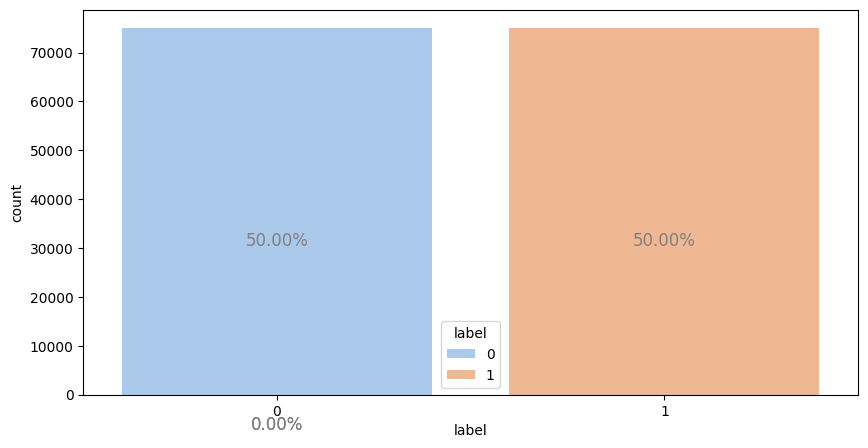

In [12]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x='label',data=df, hue='label', palette='pastel')
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()/df.shape[0]*100:.2f}%',
                 (p.get_x() + p.get_width()/2, p.get_height()/2), ha='center', va='top', color='gray', size=12)
plt.show()

In [13]:
#check for nulls
df.isna().sum()

job_id                   0
resume_id                0
label                    0
r_role                   0
r_seniority              0
r_years_experience       0
r_industry               0
r_education              0
r_skills                 0
r_summary                0
r_experience_bullets     0
j_job_title              0
j_seniority              0
j_industry               0
j_must_have_skills       0
j_nice_to_have_skills    0
j_description            0
j_responsibilities       0
j_requirements           0
dtype: int64

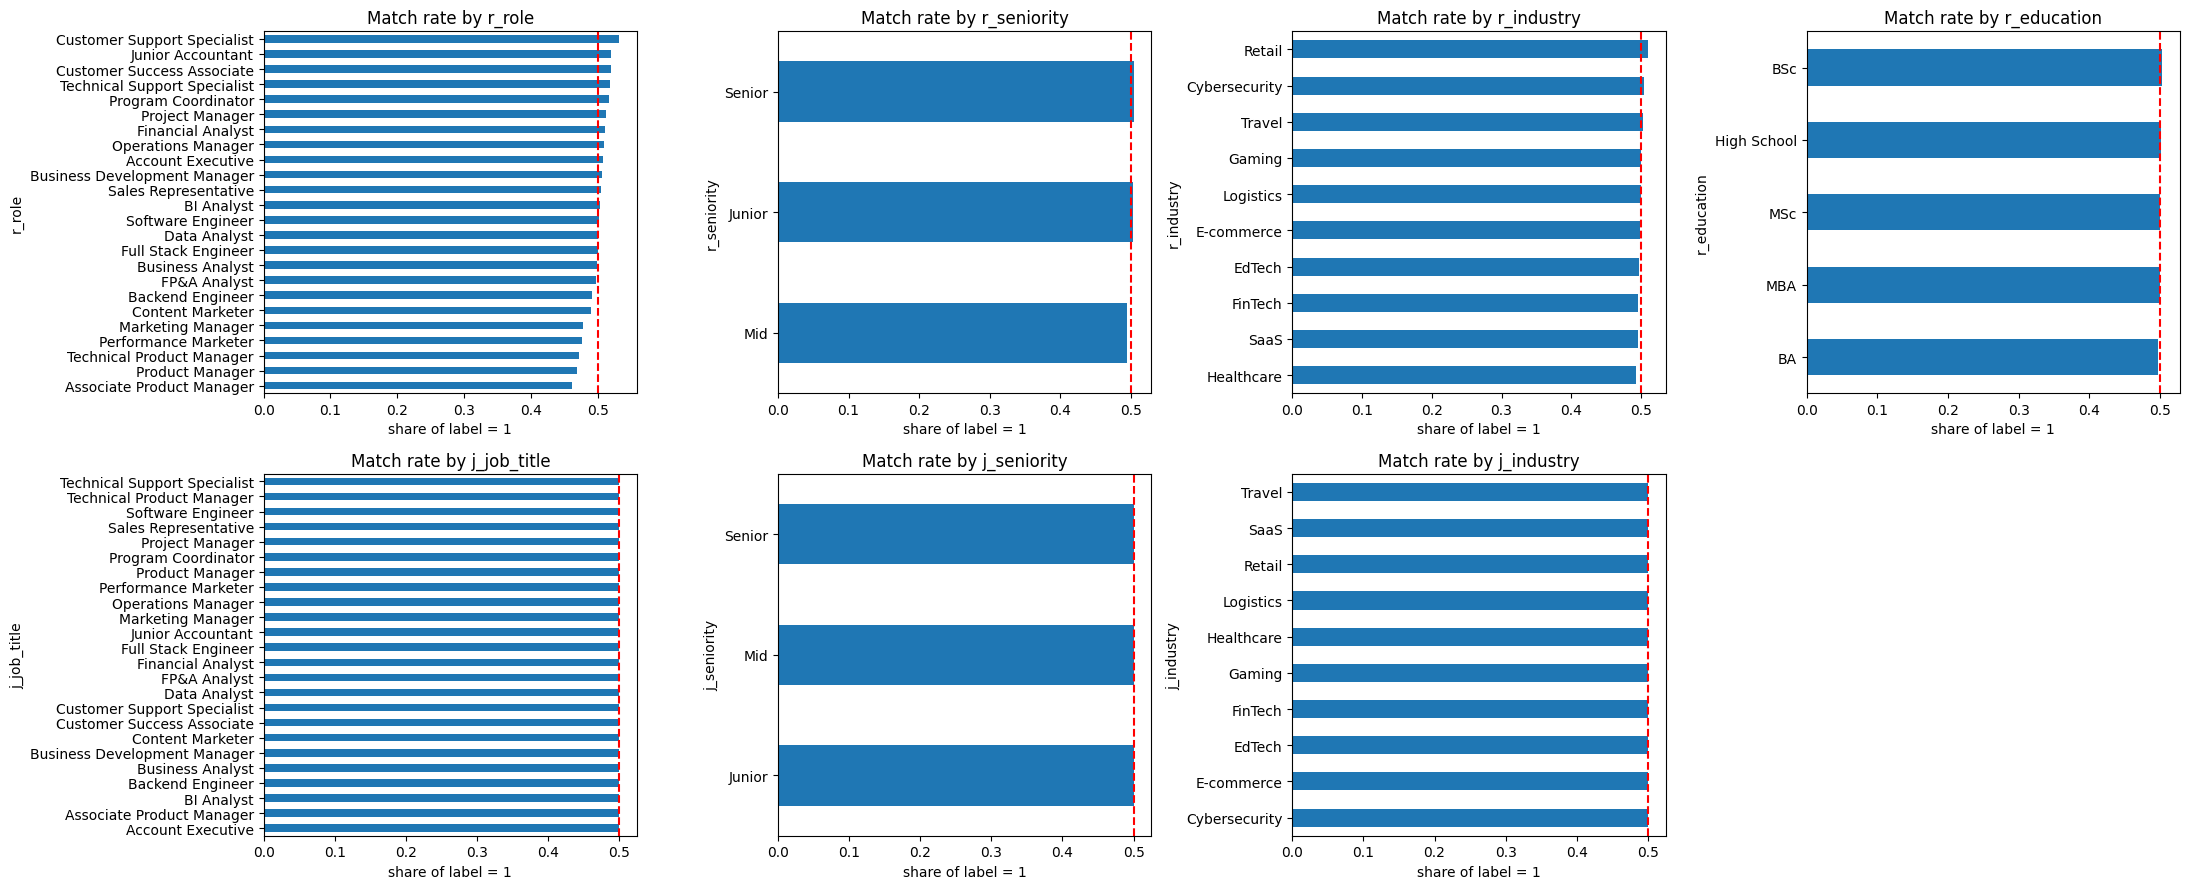

In [14]:
cat_cols = ["r_role", "r_seniority", "r_industry", "r_education",
            "j_job_title", "j_seniority", "j_industry"]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)["label"].mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.axvline(0.5, color="red", ls="--")   # 50% = no signal
    ax.set_title(f"Match rate by {col}")
    ax.set_xlabel("share of label = 1")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

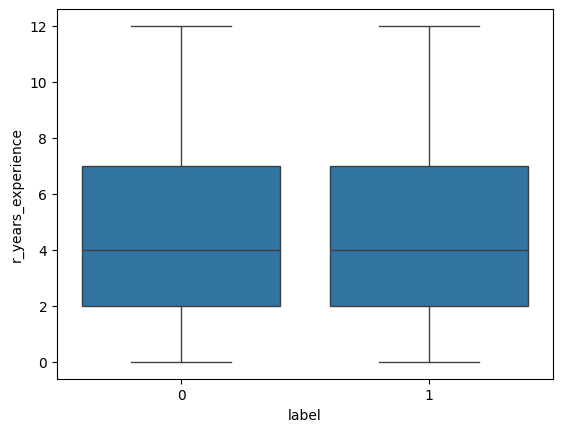

In [15]:
sns.boxplot(data=df, x="label", y="r_years_experience")
plt.show()

### Pair-Level Features

New columns that compare each candidate with each job (one row = one pair):

- `role_match`: 1 if the candidate's role equals the job title, else 0
- `seniority_match`: 1 if the seniority levels are equal, else 0
- `industry_match`: 1 if the industries are equal, else 0
- `must_have_overlap`: shared must-have skills / total must-have skills (0 to 1)

**Example:** a job needs 5 skills and the candidate has 3 of them, so `must_have_overlap = 3/5 = 0.6`.

**Note:** the dataset labels a pair as a match (`label = 1`) when `must_have_overlap >= 0.6`, so this feature leaks the label. Models will be tested with and without it.

In [16]:
df["role_match"]      = (df["r_role"] == df["j_job_title"]).astype(int)
df["seniority_match"] = (df["r_seniority"] == df["j_seniority"]).astype(int)
df["industry_match"]  = (df["r_industry"] == df["j_industry"]).astype(int)

def overlap(r, j):
    j = set(j.split("|"))
    return len(set(r.split("|")) & j) / len(j)

df["must_have_overlap"] = [overlap(r, j) for r, j in zip(df["r_skills"], df["j_must_have_skills"])]

### Distribution of Must-Have Skill Overlap by Label

**Question:** How does the share of the job's required skills that a candidate has (`must_have_overlap`) differ between matches and non-matches?

**How to read the chart:** The x-axis is `must_have_overlap` (0 = no required skills, 1 = all of them). Orange bars are **Match** (`label = 1`) and blue bars are **Don't Match** (`label = 0`). The y-axis is density. Each class is normalized separately (`common_norm=False`), so the chart compares the **shape** of each class, not how many pairs it has. The smooth lines are KDE curves fitted over the bars.

**Findings:**
- **Matches start at exactly 0.6.** No match sits below 0.6, and most fall between 0.6 and 1.0. This is the dataset's rule: a pair is a match only when at least 60% of the must-have skills are covered.
- **Non-matches pile up at 0.0.** Most non-matches share none of the job's required skills, which makes them easy negatives.
- **A few non-matches sit between 0.2 and 0.5.** These are hard negatives with partial overlap, and there are very few of them.
- **A few non-matches sit at 0.6 and above** (small blue bars under the orange ones). These pairs meet the 60% rule but are labeled `label = 0`, so they are **label noise** that should be removed in the cleaning step.

**Notes:**
- The bars are separated and the curves wiggle because a job has only 3-5 must-have skills, so overlap can take only a few values (0, 0.2, 0.25, 0.33, 0.4, 0.5, 0.6, 0.67, 0.75, 0.8, 1.0). The waves in the KDE lines come from this and are not real patterns.
- The two classes barely overlap, so a single threshold at 0.6 separates them almost perfectly.

**Conclusion:** `must_have_overlap` separates matches from non-matches almost completely, because the label was built from this same rule. This is **label leakage**, so models will be evaluated both **with** and **without** the skill-overlap features.

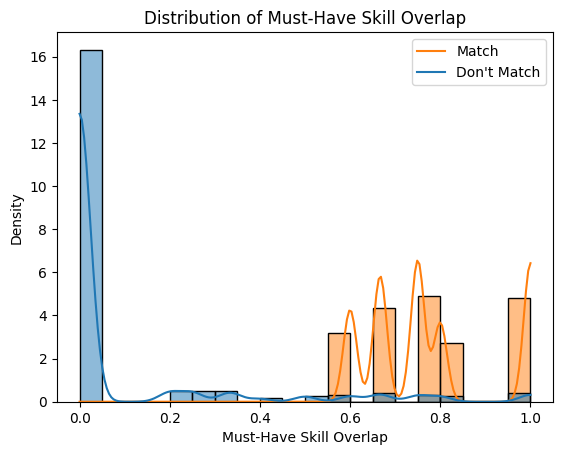

In [17]:
sns.histplot(
    data=df,
    x="must_have_overlap",
    hue="label",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of Must-Have Skill Overlap")
plt.xlabel("Must-Have Skill Overlap")
plt.ylabel("Density")
plt.legend(["Match", "Don't Match"])
plt.show()

### Role Match vs. Match Rate

**Question:** If a candidate's role is the same as the job title, is the pair more likely to be a match?

**How to read the chart:** Each bar shows the percentage of candidate-job pairs labeled as a match (`label = 1`) within its group. "Same role" means `r_role == j_job_title`, and "Different role" means they differ.

**Findings:**
- About **89%** of pairs with the same role are matches, compared with about **41%** of pairs with a different role.
- A role match therefore increases the chance of a match, which makes `role_match` a useful feature.
- The reason is that the label doesn't depend on the role. It depends on skills overlap, so its not a must to be a match just because someone has the same job as there role

**Note:** The dataset is balanced (50% matches overall), so the bars should be compared with each other and with the 50% baseline.

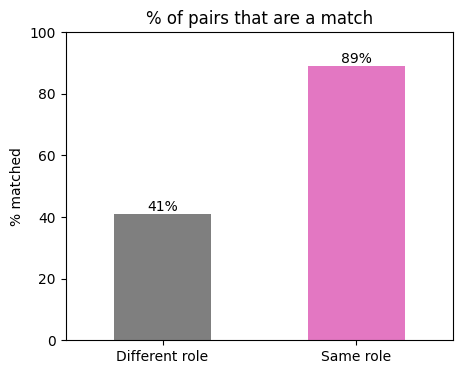

In [18]:
rate = df.groupby("role_match")["label"].mean() * 100
rate.index = ["Different role", "Same role"]
ax = rate.plot(kind="bar", color=["tab:gray", "tab:pink"], figsize=(5, 4))
ax.bar_label(ax.containers[0], fmt="%.0f%%")
plt.title("% of pairs that are a match")
plt.ylabel("% matched")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

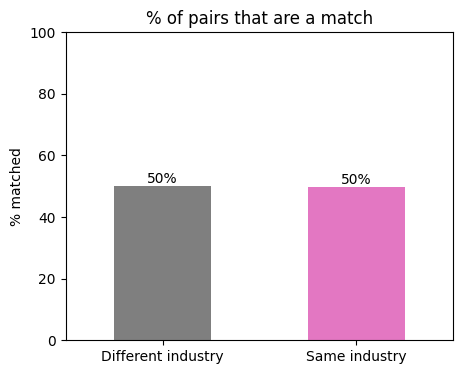

In [19]:
rate = df.groupby("industry_match")["label"].mean() * 100
rate.index = ["Different industry", "Same industry"]
ax = rate.plot(kind="bar", color=["tab:gray", "tab:pink"], figsize=(5, 4))
ax.bar_label(ax.containers[0], fmt="%.0f%%")
plt.title("% of pairs that are a match")
plt.ylabel("% matched")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

### Skill Coverage vs. Match Rate

**Question:** How does the share of the job's must-have skills that a candidate has relate to whether the pair is a match?

**How the chart was built:** For each pair, `must_have_overlap` is the fraction of the job's must-have skills that appear in the candidate's skills. Pairs were grouped into three bands: **None (0%)**, **Some (1-59%)** and **Most (60%+)**. Each bar shows the percentage of pairs in that band with `label = 1`.

**Findings:**
- With **60% or more** of the must-have skills covered, about **92%** of the pairs are matches.
- With **no** shared must-have skills, or only **partial** overlap (1-59%), almost none of the pairs are matches (about 0%).
- The label does not rise gradually. It jumps from 0 to 1 at the 60% threshold, which is the rule the dataset uses to define a match.

**Data quality note:** The 60%+ bar is not exactly 100%. Some pairs meet the 60% rule but are labeled `label = 0`. Under the dataset's own definition these should be matches, so they count as label noise and will be removed in the data cleaning step.

**Why it matters (label leakage):** Because the label comes directly from skill overlap, `must_have_overlap` and related features let a model reach very high scores by rediscovering the rule. For this reason, the models will be evaluated both **with** and **without** the direct skill-overlap features, and this limitation will be stated in the results.

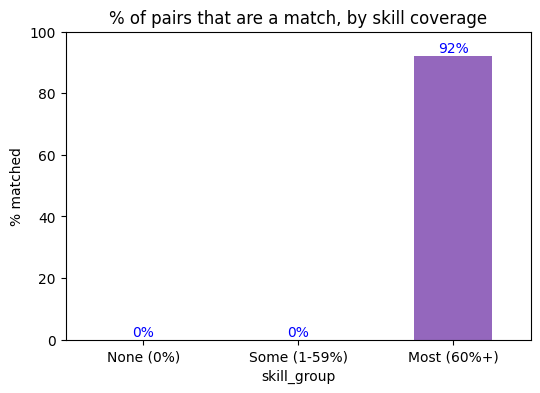

In [20]:
df["skill_group"] = pd.cut(
    df["must_have_overlap"],
    bins=[-0.01, 0, 0.59, 1],
    labels=["None (0%)", "Some (1-59%)", "Most (60%+)"])

rate = df.groupby("skill_group")["label"].mean() * 100
ax = rate.plot(kind="bar", color=["tab:red", "tab:orange", "tab:purple"], figsize=(6, 4))
ax.bar_label(ax.containers[0], fmt="%.0f%%" ,color="blue")
plt.title("% of pairs that are a match, by skill coverage")
plt.ylabel("% matched")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

## Combine your four matching features

### Average of Match Features by Label

For each class (`label = 0` and `label = 1`), the table shows the mean of the four pair-level features.

- For `role_match`, `seniority_match` and `industry_match` (0 or 1), the mean is the **share of pairs where the two sides agree**.
- For `must_have_overlap` (0 to 1), the mean is the **average skill coverage**.

**Findings:**
- `must_have_overlap`: about **0.78** for matches vs **0.10** for non-matches. This is the biggest gap, because the label is built from skill overlap.
- `role_match`: about **33%** of matches vs **4%** of non-matches, so it is a useful hint.
- `seniority_match` (~33%) and `industry_match` (~10%) are the same in both classes, which is chance level, so they carry almost no signal on their own.

**Conclusion:** Skill overlap and role match separate the classes, while seniority and industry do not.

In [21]:
df.groupby("label")[
    [
        "role_match",
        "seniority_match",
        "industry_match",
        "must_have_overlap"
    ]
].mean()

,role_match,seniority_match,industry_match,must_have_overlap
label,,,,
0,0.040627,0.333840,0.100507,0.095570
1,0.332080,0.335867,0.099960,0.774806


### Average Matching Features by Label

The chart compares the average of the four pair-level features for non-matches (`label = 0`) and matches (`label = 1`).

**Findings:**
- **`must_have_overlap`:** about **0.78** for matches vs **0.10** for non-matches. This is the largest gap, so high skill overlap occurs mostly in class 1.
- **`role_match`:** about **0.33** for matches vs **0.04** for non-matches, so it is a smaller but useful hint.
- **`seniority_match`** (~0.33) and **`industry_match`** (~0.10) are the same in both classes, so they do not help separate matches from non-matches.

**Conclusion:** Skill overlap separates the classes clearly, and role match helps a little. Seniority and industry agreement are at chance level and carry almost no signal on their own.

**Note:** Because the label is defined from skill overlap, `must_have_overlap` leaks the label, so models will be tested with and without it.

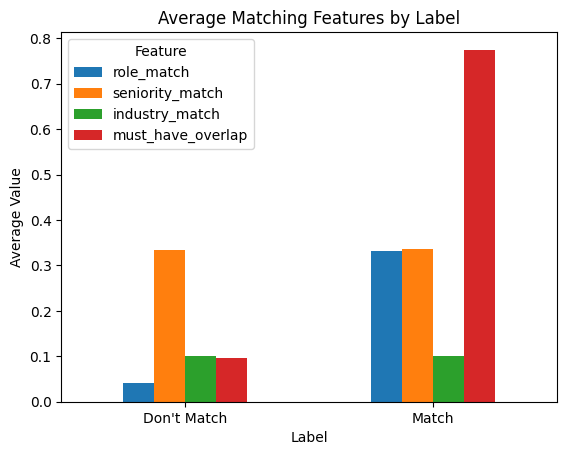

In [22]:
feature_means = df.groupby("label")[
    [
        "role_match",
        "seniority_match",
        "industry_match",
        "must_have_overlap"
    ]
].mean()

feature_means.plot(kind="bar")

plt.title("Average Matching Features by Label")
plt.xlabel("Label")
plt.ylabel("Average Value")
plt.xticks([0, 1], ["Don't Match", "Match"], rotation=0)
plt.legend(title="Feature")
plt.show()

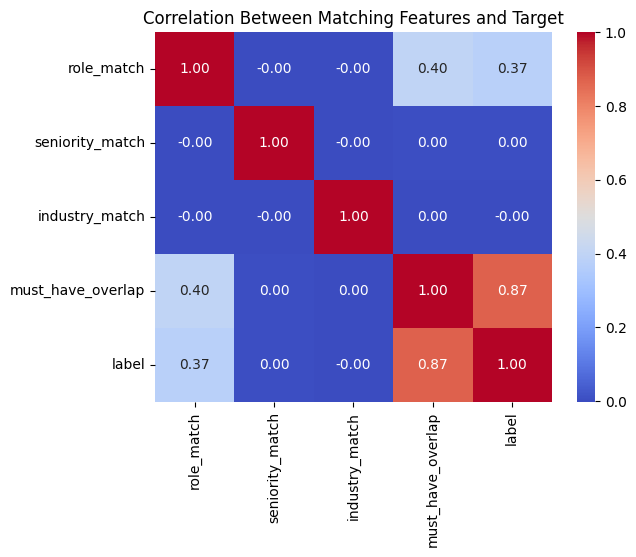

In [23]:
corr_cols = [
    "role_match",
    "seniority_match",
    "industry_match",
    "must_have_overlap",
    "label"
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Matching Features and Target")
plt.show()

# 2. Preprocessing

## 2.1. Remove noisy rows

In [24]:
# Find noisy rows
noise_mask = (df["label"] == 0) & (df["must_have_overlap"] >= 0.6)

print("Noisy rows:", noise_mask.sum())

# Remove noisy rows
df_clean = df[~noise_mask].reset_index(drop=True)

print("Before:", df.shape)
print("After:", df_clean.shape)

# Check labels after cleaning
print(df_clean["label"].value_counts())
print(df_clean["label"].value_counts(normalize=True).round(3))

Noisy rows: 6364
Before: (150000, 24)
After: (143636, 24)
label
1    75000
0    68636
Name: count, dtype: int64
label
1    0.522
0    0.478
Name: proportion, dtype: float64


In [25]:
print(df["r_experience_bullets"].nunique())
print(df["j_responsibilities"].nunique())
print(df["j_requirements"].nunique())

1
1
1


In [26]:
# Drop leaking column, EDA helper columns and constant columns
df_clean = df_clean.drop(
    columns=[
        "skill_group",           # leaking column
        "must_have_overlap",     # leaking column (recomputed later in the feature function)
        "role_match",            # EDA helper (recomputed later)
        "seniority_match",       # EDA helper (recomputed later)
        "industry_match",        # EDA helper (recomputed later)
        "r_experience_bullets",  # constant
        "j_responsibilities",    # constant
        "j_requirements"         # constant
    ]
)

print(df_clean.shape)

(143636, 16)


## 2.2. To convert the ( | ) into ( , ) for the nlp

In [27]:
def split_pipe(x):
    if isinstance(x, str) and x != "":
        return x.split("|")
    return []

In [28]:
list_cols = [
    "r_skills",
    "j_must_have_skills",
    "j_nice_to_have_skills"
]

for col in list_cols:
    df_clean[col] = df_clean[col].map(split_pipe)

In [29]:
df_clean[list_cols].head()

,r_skills,j_must_have_skills,j_nice_to_have_skills
0,"[Asana, KPIs, Project Planning, Risk Managemen...","[Asana, Jira, Process Improvement, Risk Manage...",[Stakeholder Communication]
1,"[JavaScript, Unit Testing, Git, CI/CD, Docker,...","[Databases, Docker, JavaScript, Python, Git]",[Java]
2,"[Scrum, Analytics, Agile, Roadmap, PRD]","[Ticketing, Documentation, Root Cause Analysis...",[Troubleshooting]
3,"[Cash Flow, Budgeting, Variance Analysis, Valu...","[Documentation, Zendesk, SLA, Root Cause Analy...",[Customer Satisfaction]
4,"[Documentation, SLA, Escalations, Zendesk, Roo...","[Outbound Outreach, Negotiation, Discovery Cal...",[Closing]


# 3. NLP Processing

Natural Language Processing (NLP) is used to process resume and job-description text and extract information that can be used for candidate-job matching.

The NLP pipeline includes:

- Text cleaning and preprocessing
- Skill extraction and normalization
- Years-of-experience extraction
- Education extraction
- Seniority extraction
- Job-role extraction
- Candidate and job profile construction

The extracted information is later used to create numerical features for the machine-learning models.

## 3.1 Skill extraction mapped to the dataset vocabulary


In [30]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9+#/\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return clean_text(text).split()


def remove_stopwords(tokens):
    return [
        token
        for token in tokens
        if token not in STOP_WORDS and len(token) > 1
    ]


def preprocess_text(text):
    return " ".join(
        remove_stopwords(
            tokenize(text)
        )
    )

In [31]:
all_skill_lists = pd.concat([
    df_clean["r_skills"],
    df_clean["j_must_have_skills"],
    df_clean["j_nice_to_have_skills"]
])

SKILL_VOCAB = sorted({
    skill
    for skill_list in all_skill_lists
    for skill in skill_list
})

print("Number of unique skills:", len(SKILL_VOCAB))
print(SKILL_VOCAB)

Number of unique skills: 73
['A/B Testing', 'Account Management', 'Accounting', 'Agile', 'Analytics', 'Asana', 'Budgeting', 'CI/CD', 'CRM', 'Cash Flow', 'Closing', 'Communication', 'Content Marketing', 'Conversion Optimization', 'Copywriting', 'Cross-functional Coordination', 'Customer Satisfaction', 'Data Visualization', 'Databases', 'Discovery Calls', 'Docker', 'Documentation', 'ETL', 'Email Marketing', 'Escalations', 'Excel', 'Financial Modeling', 'Forecasting', 'Git', 'Google Ads', 'Intercom', 'Java', 'JavaScript', 'Jira', 'KPIs', 'Landing Pages', 'Lead Generation', 'Marketing Analytics', 'Meta Ads', 'Negotiation', 'OOP', 'Outbound Outreach', 'PRD', 'Pandas', 'Pipeline Management', 'Power BI', 'Prioritization', 'Process Improvement', 'Product Strategy', 'Project Planning', 'Prospecting', 'Python', 'REST APIs', 'Reporting', 'Risk Management', 'Roadmap', 'Root Cause Analysis', 'SEO', 'SLA', 'SQL', 'Scrum', 'Stakeholder Communication', 'Stakeholder Management', 'Statistics', 'Tableau'

In [32]:
SKILL_ALIASES = {
    "js": "JavaScript",
    "node.js": "JavaScript",
    "nodejs": "JavaScript",
    "react": "JavaScript",
    "typescript": "JavaScript",

    "postgresql": "Databases",
    "mysql": "Databases",
    "mongodb": "Databases",
    "database": "Databases",
    "nosql": "Databases",

    "restful": "REST APIs",
    "restful api": "REST APIs",
    "restful apis": "REST APIs",
    "rest api": "REST APIs",
    "rest apis": "REST APIs",

    "object oriented programming": "OOP",
    "object-oriented programming": "OOP",

    "unit tests": "Unit Testing",
    "pytest": "Unit Testing",
    "junit": "Unit Testing",

    "continuous integration": "CI/CD",
    "continuous deployment": "CI/CD",

    "containers": "Docker",
    "containerization": "Docker",

    "github": "Git",
    "gitlab": "Git",
    "version control": "Git",

    "microsoft excel": "Excel",

    "powerbi": "Power BI",

    "data viz": "Data Visualization",
    "dashboards": "Data Visualization",

    "a/b test": "A/B Testing",

    "kanban": "Agile",
    "sprint planning": "Agile",

    "salesforce": "CRM",
    "hubspot": "CRM",

    "google adwords": "Google Ads",
    "ppc": "Google Ads",

    "facebook ads": "Meta Ads",
    "instagram ads": "Meta Ads",

    "product requirements": "PRD",
    "product requirements document": "PRD",

    "financial models": "Financial Modeling",

    "rca": "Root Cause Analysis",

    "service level agreement": "SLA",

    "cold outreach": "Outbound Outreach",
    "cold calling": "Outbound Outreach",

    "help desk": "Ticketing",
    "issue tracking": "Ticketing",

    "kpi": "KPIs",

    "data analytics": "Analytics",
    "google analytics": "Analytics",

    "extract transform load": "ETL",

    "budget": "Budgeting",

    "forecast": "Forecasting",

    "roadmapping": "Roadmap",
    "product roadmap": "Roadmap",
}

# Every alias target must exist in the 73-skill vocabulary (should print [])
print([t for t in set(SKILL_ALIASES.values()) if t not in SKILL_VOCAB])


[]


In [33]:
ALIAS_TO_SKILL = {
    skill.lower(): skill
    for skill in SKILL_VOCAB
}

for alias, target in SKILL_ALIASES.items():
    if target in SKILL_VOCAB:
        ALIAS_TO_SKILL[alias.lower()] = target

_ALIAS_PATTERNS = sorted(
    ALIAS_TO_SKILL.keys(),
    key=len,
    reverse=True
)

_ALIAS_REGEX = [
    (
        re.compile(rf"(?<!\w){re.escape(alias)}(?!\w)"),
        ALIAS_TO_SKILL[alias]
    )
    for alias in _ALIAS_PATTERNS
]

In [34]:
def extract_skills(text):
    text = str(text).lower()
    found = []

    for pattern, skill in _ALIAS_REGEX:
        if pattern.search(text):
            found.append(skill)
            text = pattern.sub(" ", text)

    return sorted(set(found))

## 3.2 Information Extraction

In addition to skills, the NLP pipeline extracts other candidate and job attributes that are useful for matching.

The extracted attributes include:

- Years of experience
- Education level
- Seniority level
- Job roles and titles
- Required experience for jobs

These attributes are later converted into candidate-job compatibility features.

In [35]:
def extract_years_experience(text):
    text = str(text).lower()

    explicit = [
        int(m)
        for m in re.findall(
            r"(\d{1,2})\s*\+?\s*(?:years?|yrs?)"
            r"\b(?:\s+of)?(?:\s+\w+){0,3}?\s+experience",
            text
        )
    ]

    explicit += [
        int(m)
        for m in re.findall(
            r"experience\s*(?:of|:)?\s*"
            r"(\d{1,2})\s*\+?\s*(?:years?|yrs?)",
            text
        )
    ]

    if explicit:
        return min(max(explicit), 40)

    covered = set()
    current_year = datetime.date.today().year

    for start, end in re.findall(
        r"\b((?:19|20)\d{2})\s*"
        r"(?:-|to|–|—)\s*"
        r"((?:19|20)\d{2}|present|current|now)\b",
        text
    ):
        start_year = int(start)

        end_year = (
            current_year
            if end in ("present", "current", "now")
            else int(end)
        )

        if 0 <= end_year - start_year <= 40:
            covered.update(
                range(start_year, max(end_year, start_year + 1))
            )

    return min(len(covered), 40)

In [36]:
EDU_RANK = {
    "High School": 0,
    "BA": 1,
    "BSc": 1,
    "MBA": 2,
    "MSc": 2,
    "PhD": 3
}


def extract_education(text):
    raw = str(text)
    low = raw.lower()

    found = []

    if re.search(r"\bph\.?d\b|doctorate|doctoral", low):
        found.append("PhD")

    if re.search(r"\bmba\b|master of business", low):
        found.append("MBA")

    if re.search(
        r"\bm\.?sc\b|master of science|"
        r"(?<!scrum )master's|\bmasters\b|master of (?!business)",
        low
    ):
        found.append("MSc")

    if re.search(
        r"\bb\.?sc\b|bachelor of science|"
        r"bachelor(?! of arts)|undergraduate degree",
        low
    ):
        found.append("BSc")

    if re.search(r"\bB\.?A\b", raw) or "bachelor of arts" in low:
        found.append("BA")

    if re.search(
        r"high school|secondary school|thanaweya",
        low
    ):
        found.append("High School")

    return (
        max(found, key=EDU_RANK.get)
        if found
        else "Unknown"
    )

In [37]:
def years_to_seniority(years):
    if years < 2:
        return "Junior"
    if years < 6:
        return "Mid"
    return "Senior"


def extract_seniority(text, years=None):
    low = str(text).lower()

    if re.search(
        r"\b(senior|sr\.?|lead(?!\s+generation)|principal|head of)\b",
        low
    ):
        return "Senior"

    if re.search(
        r"\b(junior|jr\.?|intern|internship|"
        r"trainee|entry[- ]level|graduate)\b",
        low
    ):
        return "Junior"

    if re.search(
        r"\b(mid[- ]level|intermediate)\b",
        low
    ):
        return "Mid"

    return (
        years_to_seniority(years)
        if years is not None
        else "Mid"
    )

In [38]:
KNOWN_ROLES = sorted(
    set(df_clean["r_role"]) | set(df_clean["j_job_title"])
)

_role_vec = TfidfVectorizer(
    ngram_range=(1, 2) # find similarity for unknowns job roles eg: ml eng -> software eng 0.42
)

_role_matrix = _role_vec.fit_transform(
    [clean_text(role) for role in KNOWN_ROLES]
)


def canonical_role(title, threshold=0.35):
    if not str(title).strip():
        return "Other"

    query = _role_vec.transform([
        clean_text(title)
    ])

    similarities = (
        _role_matrix @ query.T
    ).toarray().ravel()

    best_idx = similarities.argmax()

    if similarities[best_idx] >= threshold:
        return KNOWN_ROLES[best_idx]

    return "Other"


def extract_job_titles(text):
    low = str(text).lower()

    hits = [
        (low.find(role.lower()), role)
        for role in KNOWN_ROLES
        if role.lower() in low
    ]

    return [role for _, role in sorted(hits)]

## 3.3 Candidate and Job Profile Builders

The extracted NLP information is combined into structured candidate and job profiles.

A candidate profile contains attributes such as:

- Role
- Seniority
- Years of experience
- Education
- Skills
- Job titles
- Processed resume text

A job profile contains:

- Job title
- Seniority
- Industry
- Required skills
- Nice-to-have skills
- Required experience
- Education requirements
- Processed job text

In [39]:
def build_candidate_profile(cv_text):
    years = extract_years_experience(cv_text)

    titles = extract_job_titles(cv_text)

    role = (
        titles[0]
        if titles
        else canonical_role(
            str(cv_text)[:200]
        )
    )

    return {
        "role": role,
        "seniority": years_to_seniority(years),
        "years_experience": years,
        "industry": "Unknown",
        "education": extract_education(cv_text),
        "skills": extract_skills(cv_text),
        "titles": titles,
        "text": preprocess_text(cv_text)
    }

In [40]:
def extract_required_years(text):
    numbers = [
        int(x)
        for x in re.findall(
            r"(\d{1,2})\s*\+?\s*(?:years?|yrs?)",
            str(text).lower()
        )
    ]

    return min(numbers) if numbers else None


def extract_education_requirement(text):
    level = extract_education(text)

    return (
        None
        if level == "Unknown"
        else level
    )


def build_job_profile(
    title,
    description,
    tags=None,
    industry="Unknown"
):
    blob = (
        f"{title} "
        f"{description} "
        f"{' '.join(tags or [])}"
    )

    required_years = extract_required_years(blob)

    return {
        "title": canonical_role(title),
        "raw_title": title,
        "seniority": extract_seniority(title, required_years),
        "industry": industry,
        "must_have": extract_skills(blob),
        "nice_to_have": [],
        "required_years": required_years,
        "education_required": extract_education_requirement(blob),
        "text": preprocess_text(f"{title} {description}")
    }

In [41]:
sample_cv = """
Ahmed Ali
Data Analyst, 2019 - Present.
BSc in Computer Science.
Skills: Python, SQL, Pandas, Power BI, Excel, Tableau.
"""

print(build_candidate_profile(sample_cv))

print(
    build_job_profile(
        "Senior Data Analyst",
        "We need 5 years of experience with SQL, Tableau and Python.",
        ["analytics"]
    )
)

{'role': 'Data Analyst', 'seniority': 'Senior', 'years_experience': 7, 'industry': 'Unknown', 'education': 'BSc', 'skills': ['Excel', 'Pandas', 'Power BI', 'Python', 'SQL', 'Tableau'], 'titles': ['Data Analyst'], 'text': 'ahmed ali data analyst 2019 present bsc computer science skills python sql pandas power bi excel tableau'}
{'title': 'Data Analyst', 'raw_title': 'Senior Data Analyst', 'seniority': 'Senior', 'industry': 'Unknown', 'must_have': ['Analytics', 'Python', 'SQL', 'Tableau'], 'nice_to_have': [], 'required_years': 5, 'education_required': None, 'text': 'senior data analyst need years experience sql tableau python'}


# 4. Candidate and Job Profiles

The training dataset already provides structured candidate and job attributes, so these fields are used directly when constructing the training profiles.

The NLP extraction functions developed above are mainly required for new resumes and job descriptions, where the information is initially unstructured text.

This keeps the training representation consistent with the representation used during inference.

## 4.1 Training Candidate Profiles

In [42]:
resumes = (
    df.drop_duplicates("resume_id")
      [
          [
              "resume_id",
              "r_role",
              "r_seniority",
              "r_years_experience",
              "r_industry",
              "r_education",
              "r_skills",
              "r_summary"
          ]
      ]
      .set_index("resume_id")
)

jobs = (
    df.drop_duplicates("job_id")
      [
          [
              "job_id",
              "j_job_title",
              "j_seniority",
              "j_industry",
              "j_must_have_skills",
              "j_nice_to_have_skills",
              "j_description"
          ]
      ]
      .set_index("job_id")
)

## 4.2 Training Job Profiles

In [43]:
cand_profiles = {
    rid: {
        "role": row.r_role,
        "seniority": row.r_seniority,
        "years_experience": int(row.r_years_experience),
        "industry": row.r_industry,
        "education": row.r_education,
        "skills": row.r_skills,
        "text": preprocess_text(
            f"{row.r_role} {row.r_summary}"
        )
    }
    for rid, row in resumes.iterrows()
}


job_profiles = {
    jid: {
        "title": row.j_job_title,
        "seniority": row.j_seniority,
        "industry": row.j_industry,
        "must_have": row.j_must_have_skills,
        "nice_to_have": row.j_nice_to_have_skills,
        "text": preprocess_text(
            f"{row.j_job_title} {row.j_description}"
        )
    }
    for jid, row in jobs.iterrows()
}

## 4.3 Profile Structure

In [44]:
sample_resume_id = next(iter(cand_profiles))
sample_job_id = next(iter(job_profiles))

print("Candidate profile:")
print(cand_profiles[sample_resume_id])

print("\nJob profile:")
print(job_profiles[sample_job_id])

Candidate profile:
{'role': 'Operations Manager', 'seniority': 'Senior', 'years_experience': 7, 'industry': 'FinTech', 'education': 'High School', 'skills': 'Asana|KPIs|Project Planning|Risk Management|Stakeholder Communication|Jira|Process Improvement|Timeline Management', 'text': 'operations manager operations manager years experience fintech'}

Job profile:
{'title': 'Operations Manager', 'seniority': 'Mid', 'industry': 'E-commerce', 'must_have': 'Asana|Jira|Process Improvement|Risk Management|KPIs', 'nice_to_have': 'Stakeholder Communication', 'text': 'operations manager hiring operations manager support teams commerce'}


# 5. Train-Test Split

A grouped split is used because the same job can appear in many candidate-job pairs.

The split is performed by `job_id` so that no job appears in both the training and test sets.

This is important because the intended application should generalize to previously unseen jobs.

## 5.1 Grouped Split by Job

### Why the Split Is Grouped by `job_id`

**The problem:** Each job appears in many rows (about 57 pairs, one per resume). A random split would put some rows of a job in train and others in test, so the model would be tested on jobs it has already seen, and the test score would look better than it really is.

**The solution:** Split the **jobs**, not the rows. About 80% of the jobs go to train and 20% go to test, and each job goes **entirely** to one side with all of its rows.

**Example with 5 jobs**

| Job | Its rows | Goes to |
|---|---|---|
| Job A | 57 pairs | Train |
| Job B | 57 pairs | Train |
| Job C | 57 pairs | Train |
| Job D | 57 pairs | Train |
| Job E | 57 pairs | Test |

**Why it matters:** The app scores live jobs the model has never seen, and a grouped split copies that situation. `set(train_data["job_id"]) & set(test_data["job_id"])` should print `set()`, confirming that no job is in both sets.

**Limitation:** Only jobs are grouped, so the same resume can still appear in both sets.

In [45]:
RANDOM_STATE = 42

# Split by job_id so the same job cannot be in train and test
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(df_clean, groups=df_clean["job_id"])
)

train_data = df_clean.iloc[train_idx].reset_index(drop=True)
test_data = df_clean.iloc[test_idx].reset_index(drop=True)



In [46]:
# Features and target
X_train = train_data.drop(columns=["label", "job_id", "resume_id"])
y_train = train_data["label"]

X_test = test_data.drop(columns=["label", "job_id", "resume_id"])
y_test = test_data["label"]

# Job IDs for grouped cross-validation later
groups_train = train_data["job_id"]
groups_test = test_data["job_id"]

In [47]:
# Checks
print(train_data.shape, test_data.shape)
print(set(train_data["job_id"]) & set(test_data["job_id"]))   # should print set()
print(X_train.columns.tolist())
print(y_train.value_counts(normalize=True).round(3).to_dict())
print(y_test.value_counts(normalize=True).round(3).to_dict())

(114881, 16) (28755, 16)
set()
['r_role', 'r_seniority', 'r_years_experience', 'r_industry', 'r_education', 'r_skills', 'r_summary', 'j_job_title', 'j_seniority', 'j_industry', 'j_must_have_skills', 'j_nice_to_have_skills', 'j_description']
{1: 0.522, 0: 0.478}
{1: 0.522, 0: 0.478}


## 5.2 Leakage Check

In [48]:
train_jobs = set(train_data["job_id"])
test_jobs = set(test_data["job_id"])

print("Shared jobs:", len(train_jobs & test_jobs))

assert train_jobs.isdisjoint(test_jobs)

print("No job appears in both training and test sets.")

Shared jobs: 0
No job appears in both training and test sets.


# 6. TF-IDF Representation

TF-IDF is used to represent resume and job-description text numerically.

To prevent information leakage, each TF-IDF vectorizer is fitted using training data only and then applied to the test data.

## 6.1 Text TF-IDF

In [49]:
train_resume_ids = train_data["resume_id"].unique()
train_job_ids = train_data["job_id"].unique()

train_resume_texts = [
    cand_profiles[rid]["text"]
    for rid in train_resume_ids
]

train_job_texts = [
    job_profiles[jid]["text"]
    for jid in train_job_ids
]

tfidf_text = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

tfidf_text.fit(
    train_resume_texts + train_job_texts
)

TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)

## 6.2 Job Title TF-IDF

In [50]:
train_title_texts = [
    cand_profiles[rid]["role"].lower()
    for rid in train_resume_ids
] + [
    job_profiles[jid]["title"].lower()
    for jid in train_job_ids
]

tfidf_title = TfidfVectorizer(
    ngram_range=(1, 2)
)

tfidf_title.fit(train_title_texts)

TfidfVectorizer(ngram_range=(1, 2))

## 6.3 Skill TF-IDF

In [51]:
train_skill_texts = [
    "|".join(cand_profiles[rid]["skills"])
    for rid in train_resume_ids
] + [
    "|".join(
        job_profiles[jid]["must_have"] +
        job_profiles[jid]["nice_to_have"]
    )
    for jid in train_job_ids
]

tfidf_skills = TfidfVectorizer(
    token_pattern=r"[^|]+"
)

tfidf_skills.fit(train_skill_texts)

TfidfVectorizer(token_pattern='[^|]+')

# 7. Feature Engineering

Candidate-job pairs are represented using several groups of features:

- Skill matching
- Experience compatibility
- Seniority compatibility
- Role compatibility
- Industry compatibility
- Text similarity

Direct skill-overlap features are retained because they are useful for demonstrating the effect of label leakage. A second feature set excluding them will be evaluated later.

## 7.1 Feature Definitions

In [52]:
SENIORITY_RANK = {
    "Junior": 0,
    "Mid": 1,
    "Senior": 2
}

SENIORITY_YEARS = {
    "Junior": (0, 2),
    "Mid": (2, 6),
    "Senior": (6, 12)
}

## 7.2 Similarity Features

In [53]:
def pair_cosine(vectorizer, texts_a, texts_b):
    texts_a = list(texts_a)
    texts_b = list(texts_b)

    unique_texts = list(
        dict.fromkeys(
            texts_a + texts_b
        )
    )

    index = {
        text: i
        for i, text in enumerate(unique_texts)
    }

    matrix = vectorizer.transform(unique_texts)

    ia = np.fromiter(
        (index[text] for text in texts_a),
        dtype=int,
        count=len(texts_a)
    )

    ib = np.fromiter(
        (index[text] for text in texts_b),
        dtype=int,
        count=len(texts_b)
    )

    return np.asarray(
        matrix[ia]
        .multiply(matrix[ib])
        .sum(axis=1)
    ).ravel()

## 7.3 Candidate-Job Compatibility Features

In [54]:
def make_features(cands, jobs):
    rows = []

    cand_texts = [
        candidate["text"]
        for candidate in cands
    ]

    job_texts = [
        job["text"]
        for job in jobs
    ]

    cand_titles = [
        candidate["role"].lower()
        for candidate in cands
    ]

    job_titles = [
        job["title"].lower()
        for job in jobs
    ]

    cand_skills_text = [
        "|".join(candidate["skills"])
        for candidate in cands
    ]

    job_skills_text = [
        "|".join(
            job["must_have"] +
            job["nice_to_have"]
        )
        for job in jobs
    ]

    text_sim = pair_cosine(
        tfidf_text,
        cand_texts,
        job_texts
    )

    title_sim = pair_cosine(
        tfidf_title,
        cand_titles,
        job_titles
    )

    skill_tfidf_sim = pair_cosine(
        tfidf_skills,
        cand_skills_text,
        job_skills_text
    )

    for i, (candidate, job) in enumerate(
        zip(cands, jobs)
    ):
        candidate_skills = set(
            candidate["skills"]
        )

        must_have = set(
            job["must_have"]
        )

        nice_to_have = set(
            job["nice_to_have"]
        )

        matching_skills = (
            candidate_skills &
            must_have
        )

        missing_skills = (
            must_have -
            candidate_skills
        )

        nice_matching = (
            candidate_skills &
            nice_to_have
        )

        union = (
            candidate_skills |
            must_have
        )

        skill_jaccard = (
            len(matching_skills) / len(union)
            if union
            else 0
        )

        required_range = SENIORITY_YEARS.get(
            job["seniority"],
            (0, 100)
        )

        candidate_years = candidate[
            "years_experience"
        ]

        exp_in_range = int(
            required_range[0]
            <= candidate_years
            <= required_range[1]
        )

        exp_gap = max(
            0,
            required_range[0] -
            candidate_years
        )

        candidate_seniority = SENIORITY_RANK.get(
            candidate["seniority"],
            1
        )

        job_seniority = SENIORITY_RANK.get(
            job["seniority"],
            1
        )

        rows.append({
            "n_must_have": len(must_have),

            "n_matching_skills": len(
                matching_skills
            ),

            "n_missing_skills": len(
                missing_skills
            ),

            "must_have_coverage": (
                len(matching_skills) /
                len(must_have)
                if must_have
                else 0
            ),

            "n_nice_matching": len(
                nice_matching
            ),

            "skill_jaccard": skill_jaccard,

            "n_candidate_skills": len(
                candidate_skills
            ),

            "skill_tfidf_sim": (
                skill_tfidf_sim[i]
            ),

            "years_experience": (
                candidate_years
            ),

            "exp_in_range": exp_in_range,

            "exp_gap": exp_gap,

            "candidate_seniority": (
                candidate_seniority
            ),

            "job_seniority": job_seniority,

            "seniority_match": int(
                candidate["seniority"] ==
                job["seniority"]
            ),

            "seniority_diff": abs(
                candidate_seniority -
                job_seniority
            ),

            "role_match": int(
                candidate["role"] ==
                job["title"]
            ),

            "industry_match": int(
                candidate["industry"] ==
                job["industry"]
            ),

            "title_sim": title_sim[i],

            "text_sim": text_sim[i]
        })

    return pd.DataFrame(rows)

## 7.4 Feature Sets

In [55]:
SKILL_FEATURES = [
    "n_must_have",
    "n_matching_skills",
    "n_missing_skills",
    "must_have_coverage",
    "n_nice_matching",
    "skill_jaccard",
    "n_candidate_skills",
    "skill_tfidf_sim"
]

NON_SKILL_FEATURES = [
    "years_experience",
    "exp_in_range",
    "exp_gap",
    "candidate_seniority",
    "job_seniority",
    "seniority_match",
    "seniority_diff",
    "role_match",
    "industry_match",
    "title_sim",
    "text_sim"
]

ALL_FEATURES = (
    SKILL_FEATURES +
    NON_SKILL_FEATURES
)

FEATURE_SETS = {
    "All Features": ALL_FEATURES,
    "Without Skill Overlap": NON_SKILL_FEATURES
}

print("Total features:", len(ALL_FEATURES))
print("Skill features:", len(SKILL_FEATURES))
print("Non-skill features:", len(NON_SKILL_FEATURES))

Total features: 19
Skill features: 8
Non-skill features: 11


## 7.5. Create Training and Test Features

In [56]:
train_features = make_features(
    [
        cand_profiles[r]
        for r in train_data["resume_id"]
    ],
    [
        job_profiles[j]
        for j in train_data["job_id"]
    ]
)

test_features = make_features(
    [
        cand_profiles[r]
        for r in test_data["resume_id"]
    ],
    [
        job_profiles[j]
        for j in test_data["job_id"]
    ]
)

print("Training features:", train_features.shape)
print("Testing features:", test_features.shape)

Training features: (114881, 19)
Testing features: (28755, 19)


In [57]:
X_train_all = train_features[ALL_FEATURES]
X_test_all = test_features[ALL_FEATURES]

y_train = train_data["label"].reset_index(drop=True)
y_test = test_data["label"].reset_index(drop=True)

assert X_train_all.isna().sum().sum() == 0
assert X_test_all.isna().sum().sum() == 0

print("Feature matrices contain no missing values.")

Feature matrices contain no missing values.


# 8. Model Training

Six classification algorithms are trained and evaluated:

- Logistic Regression
- Support Vector Machine
- Random Forest
- XGBoost
- LightGBM
- Multinomial Naïve Bayes

Each model is evaluated using both feature sets.

### Model Evaluation Helper

`evaluate_model` trains one model, evaluates it on the test set, and stores the results. It is reused for every model and feature set (4 models × with / without skill-overlap features), so the same steps are applied identically each time.

**What it does:**
1. **Clones the model** so each run starts from a fresh, untrained copy. Without this, reusing the same model object for the "with" and "without" runs would overwrite the earlier one.
2. **Trains** the model on the training set.
3. **Predicts** match / no match on the test set (jobs the model has never seen).
4. **Gets a score per pair** for ROC-AUC, using `predict_proba` or, for models like `LinearSVC` that lack it, `decision_function`.
5. **Computes** Accuracy, Precision, Recall, F1 and ROC-AUC.
6. **Stores** the metrics in `results`, the trained model in `fitted_models`, and the confusion matrix in `confusions`, each keyed by feature set and model name.

**Usage:** call it once per model and feature set, then build the comparison table with `pd.DataFrame(results)`.

**Note:** `y_train` and `y_test` are read from the notebook, so they must stay aligned with the rows of the feature tables passed in.

In [58]:
from sklearn.base import clone

results = []
fitted_models = {}
confusions = {}


def evaluate_model(
    model,
    model_name,
    feature_set_name,
    X_train,
    X_test
):
    # Fresh, untrained copy so every run is independent
    model = clone(model)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    else:
        probabilities = model.decision_function(
            X_test
        )

    metrics = {
        "Features": feature_set_name,
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    }

    results.append(metrics)

    fitted_models[
        (feature_set_name, model_name)
    ] = model

    confusions[
        (feature_set_name, model_name)
    ] = confusion_matrix(
        y_test,
        predictions
    )

## 8.1 Logistic Regression

In [59]:
for feature_set_name, features in FEATURE_SETS.items():

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ])

    evaluate_model(
        model,
        "Logistic Regression",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

## 8.2 Support Vector Machine

In [60]:
for feature_set_name, features in FEATURE_SETS.items():

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LinearSVC(
                C=1.0,
                max_iter=5000,
                random_state=RANDOM_STATE
            )
        )
    ])

    evaluate_model(
        model,
        "SVM",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

## 8.3 Random Forest

In [61]:
for feature_set_name, features in FEATURE_SETS.items():

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    evaluate_model(
        model,
        "Random Forest",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

## 8.4 XGBoost

In [62]:
for feature_set_name, features in FEATURE_SETS.items():

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,  # 80% of training rows
        colsample_bytree=0.8, # 80% of features per tree
        eval_metric="logloss", #Use Log Loss to measure how good the predictions are during training.
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    evaluate_model(
        model,
        "XGBoost",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

## 8.5 LightGBM

In [63]:
from lightgbm import LGBMClassifier
for feature_set_name, features in FEATURE_SETS.items():

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    evaluate_model(
        model,
        "LightGBM",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

## 8.6 Multinomial Naïve Bayes

Multinomial Naïve Bayes is a fast probabilistic model that assumes the features are **non-negative** and independent of each other. It is the classic text-classification model, and here it gets the same pair features as the other models.

- All of our features are already `>= 0`, but their scales are very different (years of experience go up to about 12, similarities are between 0 and 1), so a `MinMaxScaler` puts them on a 0 to 1 scale first. `clip=True` makes sure a new CV with a value outside the training range can never send a negative number to the model.
- This is the **baseline** with the default `alpha=1.0`. Optuna tunes it later, together with the other models.

In [64]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

for feature_set_name, features in FEATURE_SETS.items():

    model = Pipeline([
        (
            "scaler",
            MinMaxScaler(clip=True)   # Multinomial NB cannot take negative values
        ),
        (
            "classifier",
            MultinomialNB(alpha=1.0)
        )
    ])

    evaluate_model(
        model,
        "Multinomial NB",
        feature_set_name,
        train_features[features],
        test_features[features]
    )

# 9. Model Evaluation

The models are evaluated using:


## 9.1 Evaluation Metrics
- **Accuracy** — proportion of correctly classified candidate-job pairs.
- **Precision** — proportion of predicted matches that are actual matches.
- **Recall** — proportion of actual matches correctly identified.
- **F1-score** — harmonic mean of precision and recall.
- **ROC-AUC** — ability of the model to distinguish between matches and non-matches across classification thresholds.

The held-out test set contains jobs that were not present in the training set.

## 9.2 Model Comparison

In [65]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    ["Features", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All Features,XGBoost,0.968006,0.957618,0.982133,0.969721,0.993507
1,All Features,LightGBM,0.967519,0.957044,0.981800,0.969264,0.993387
2,All Features,Random Forest,0.963658,0.953055,0.978533,0.965626,0.992375
3,All Features,Logistic Regression,0.946618,0.941910,0.956667,0.949231,0.984781
4,All Features,SVM,0.945401,0.939982,0.956400,0.948120,0.984738
5,All Features,Multinomial NB,0.791862,0.955902,0.630067,0.759513,0.932375
6,Without Skill Overlap,LightGBM,0.854773,0.952887,0.759133,0.845046,0.888349
7,Without Skill Overlap,XGBoost,0.854634,0.953935,0.757933,0.844714,0.887672
8,Without Skill Overlap,Random Forest,0.845349,0.933744,0.757267,0.836297,0.880086
9,Without Skill Overlap,SVM,0.805912,0.869402,0.738933,0.798876,0.836230


## 9.3 F1-Score Comparison

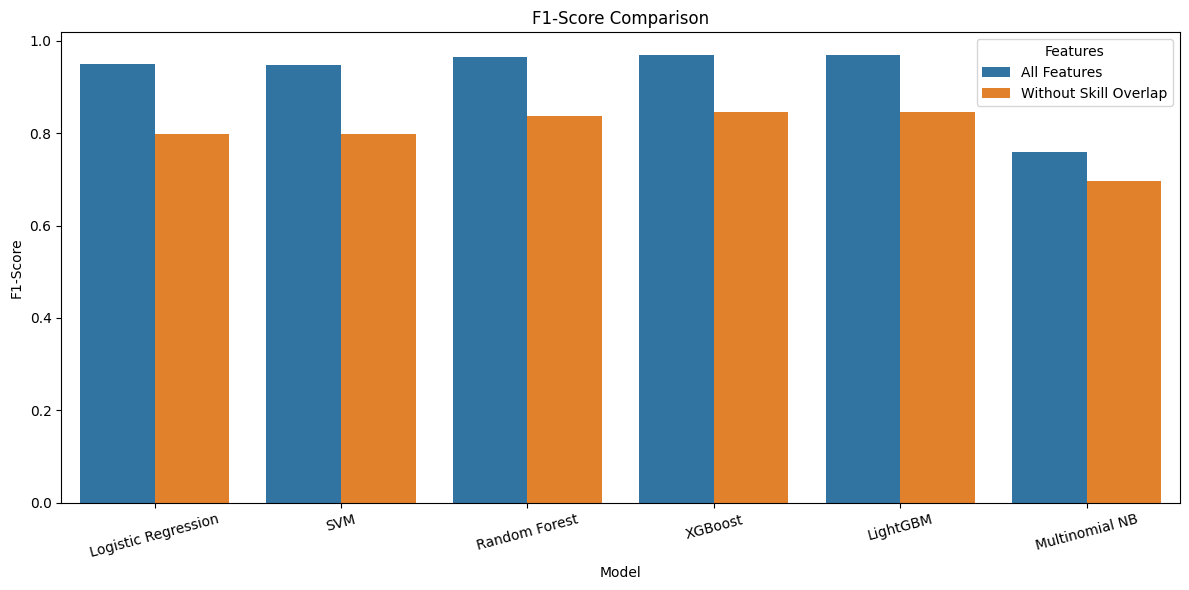

In [66]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pd.DataFrame(results),
    x="Model",
    y="F1",
    hue="Features",
    
)

plt.title("F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 9.4 Confusion Matrices

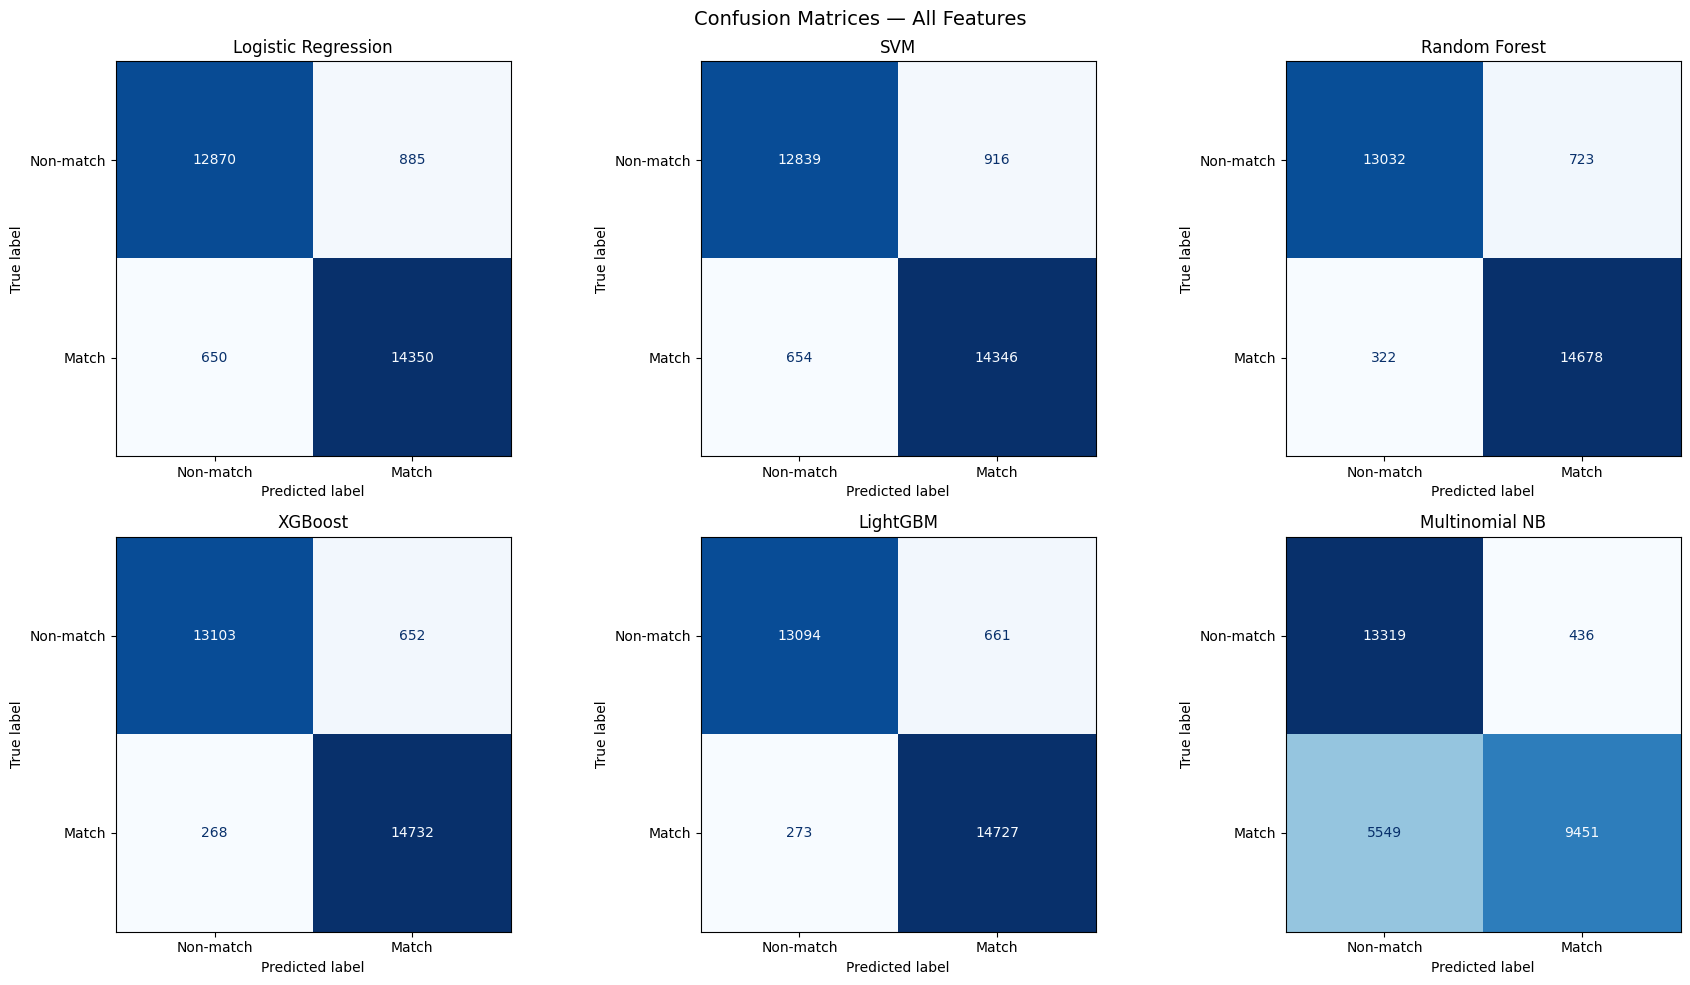

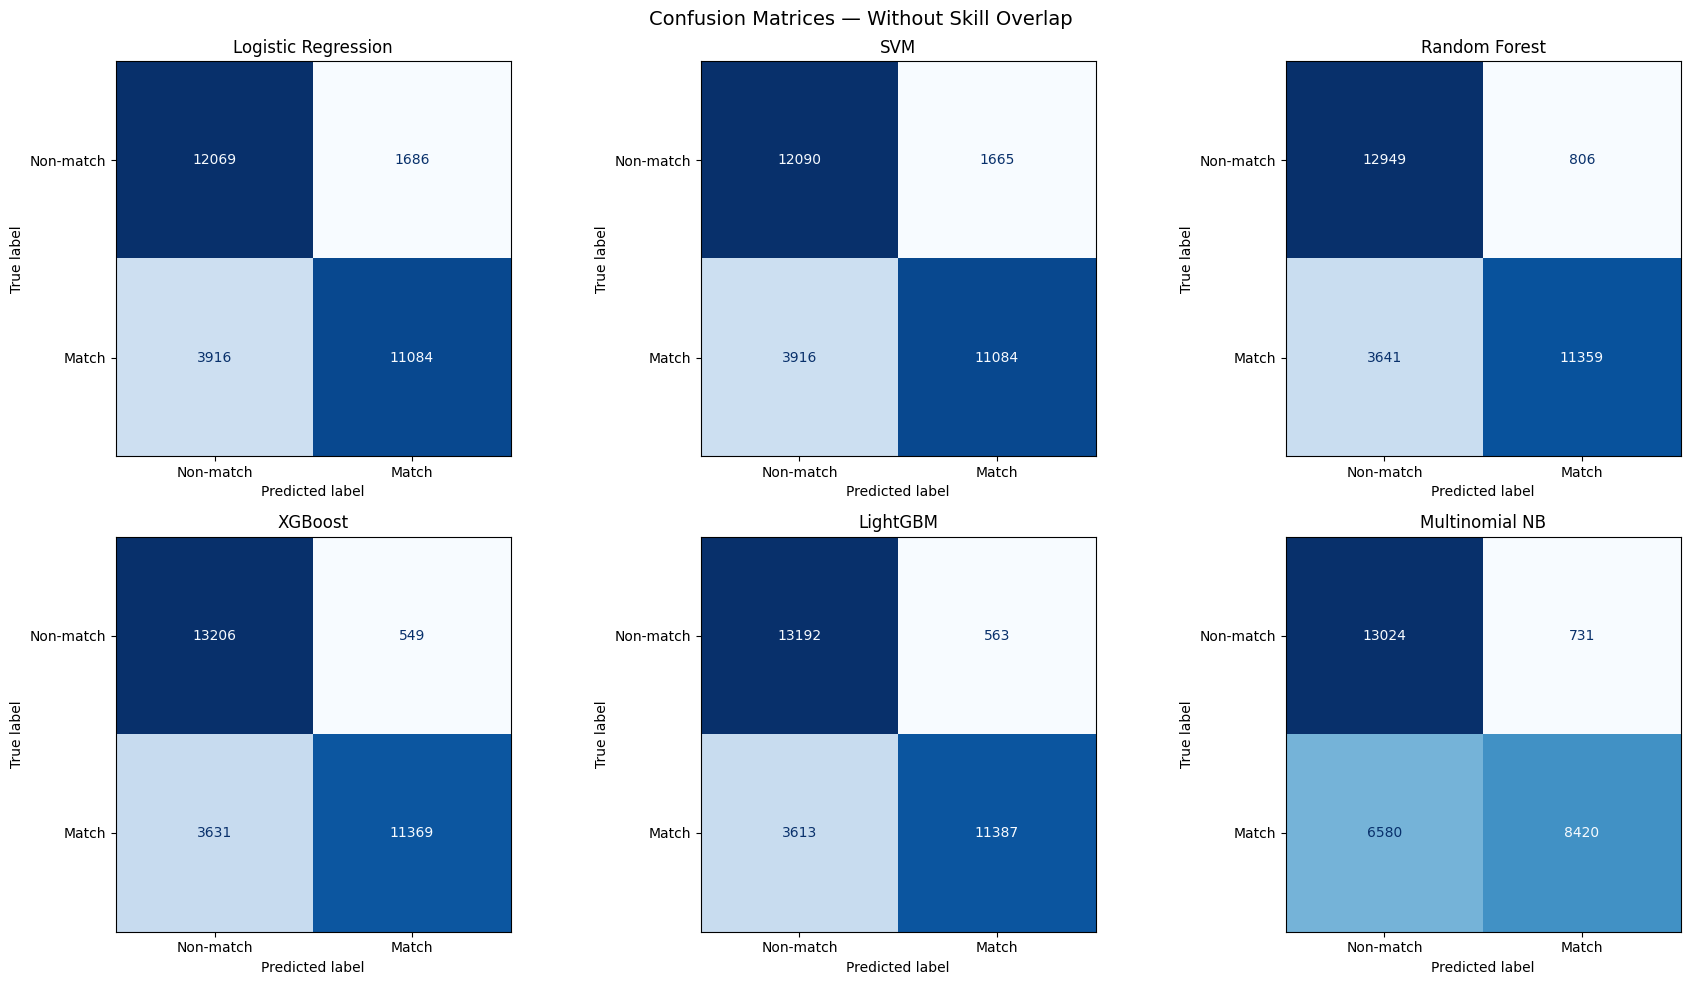

In [67]:
model_names = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "Multinomial NB"
]

for feature_set_name in FEATURE_SETS:

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 10)
    )

    axes = axes.ravel()

    for ax, model_name in zip(axes, model_names):
        cm = confusions[
            (feature_set_name, model_name)
        ]

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Non-match", "Match"]
        ).plot(
            ax=ax,
            values_format="d",
            colorbar=False, cmap="Blues"
        )

        ax.set_title(model_name)

    # Hide any unused slots
    for ax in axes[len(model_names):]:
        ax.axis("off")

    fig.suptitle(
        f"Confusion Matrices — {feature_set_name}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

### Model Results: With vs. Without Skill-Overlap Features

Five models were trained on the same grouped split and tested on **28,755 pairs from jobs the models had never seen** (13,755 non-matches and 15,000 matches). Each model was trained twice: once with all features, and once without the direct skill-overlap features.

| Features | Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| All features | Logistic Regression | 0.947 | 0.942 | 0.957 | 0.949 |
| All features | SVM | 0.945 | 0.940 | 0.956 | 0.948 |
| All features | Random Forest | 0.964 | 0.953 | 0.979 | 0.966 |
| All features | XGBoost | 0.968 | 0.957 | 0.982 | 0.969 |
| All features | LightGBM | 0.968 | 0.957 | 0.982 | 0.969 |
| Without skill overlap | Logistic Regression | 0.805 | 0.868 | 0.739 | 0.798 |
| Without skill overlap | SVM | 0.806 | 0.869 | 0.739 | 0.799 |
| Without skill overlap | Random Forest | 0.845 | 0.934 | 0.757 | 0.836 |
| Without skill overlap | XGBoost | 0.854 | 0.953 | 0.759 | 0.845 |
| Without skill overlap | LightGBM | 0.855 | 0.953 | 0.759 | 0.845 |

#### What precision and recall mean here
- **Precision = TP / (TP + FP).** Of the pairs the model called a match, how many really are matches. A low precision means the app would recommend jobs the candidate does not fit.
- **Recall = TP / (TP + FN).** Of all the real matches, how many the model found. A low recall means the app would hide jobs the candidate does fit.

#### Findings
- **Leakage is visible in the scores.** With the skill-overlap features, accuracy is 94.5% to 96.8%. Without them it falls to 80.5% to 85.5%. The label was built from skill overlap, so giving the models that feature lets them rediscover the rule.
- **The biggest drop is in recall, not precision.** Recall falls from about 0.96 to 0.98 down to about 0.74 to 0.76. The missed matches (false negatives) rise from 269 to 3,619 for XGBoost, about 13 times more.
- **Precision stays high for the tree models.** XGBoost and LightGBM keep a precision of about 0.95 in both setups, and Random Forest drops only from 0.953 to 0.934. The linear models fall further (from about 0.94 to 0.87).
- **Why.** Without skill overlap, the models are cautious. When they say "match" they are usually right, but they miss about a quarter of the real matches, because the remaining features (for example role match) identify only some of them.
- **Model comparison.** The boosted trees (XGBoost and LightGBM) are the best in both setups and nearly identical. The linear models (Logistic Regression and SVM) are the weakest without skill overlap, so the non-linear models are better at using the remaining features.

#### Conclusion
The **"All features"** scores mostly measure how well a model rediscovers the labeling rule, so they should not be read as real-world accuracy. The **"Without skill overlap"** scores are the more honest estimate of how well the models can predict a match from role, seniority, experience and the other features. Both results are reported, and the limitation is stated: the dataset is synthetic and its labels come from skill overlap.

### 9.5 With vs Without Skill-Overlap Features

The model results are compared using:

1. All engineered features.
2. Features excluding direct skill-overlap measurements.

A large performance difference between the two settings indicates that the matching rule used to generate the dataset is strongly reflected in the skill-overlap features.

The second setting provides a more informative evaluation of whether the models can identify matches using information beyond the direct matching rule.

In [68]:
comparison = (
    results_df
    .pivot(
        index="Model",
        columns="Features",
        values="F1"
    )
)

comparison

Features,All Features,Without Skill Overlap
Model,,
LightGBM,0.969264,0.845046
Logistic Regression,0.949231,0.798272
Multinomial NB,0.759513,0.697280
Random Forest,0.965626,0.836297
SVM,0.948120,0.798876
XGBoost,0.969721,0.844714


# 10. Feature Importance

Feature importance is examined for the tree-based models using the feature set without direct skill-overlap features.

This helps identify which non-overlap characteristics contribute most to the model's predictions.

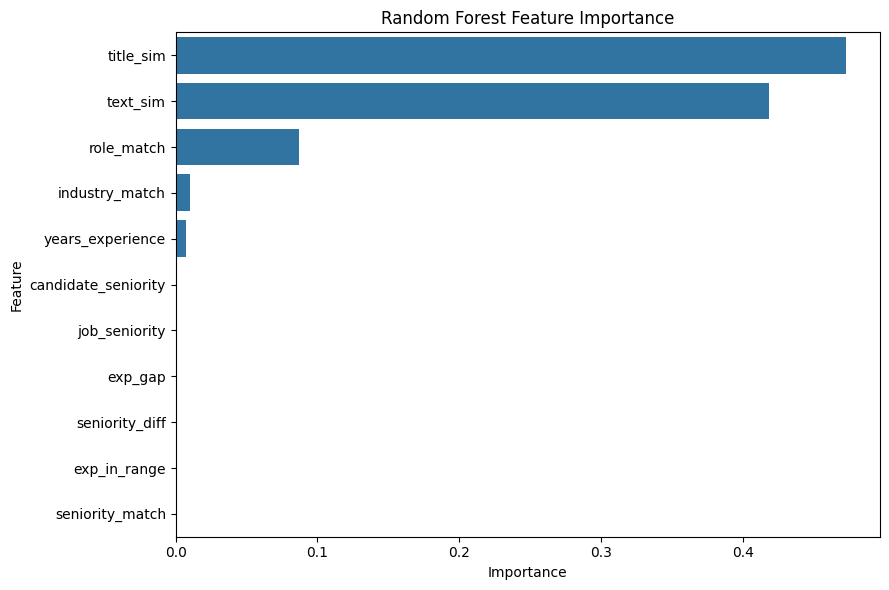

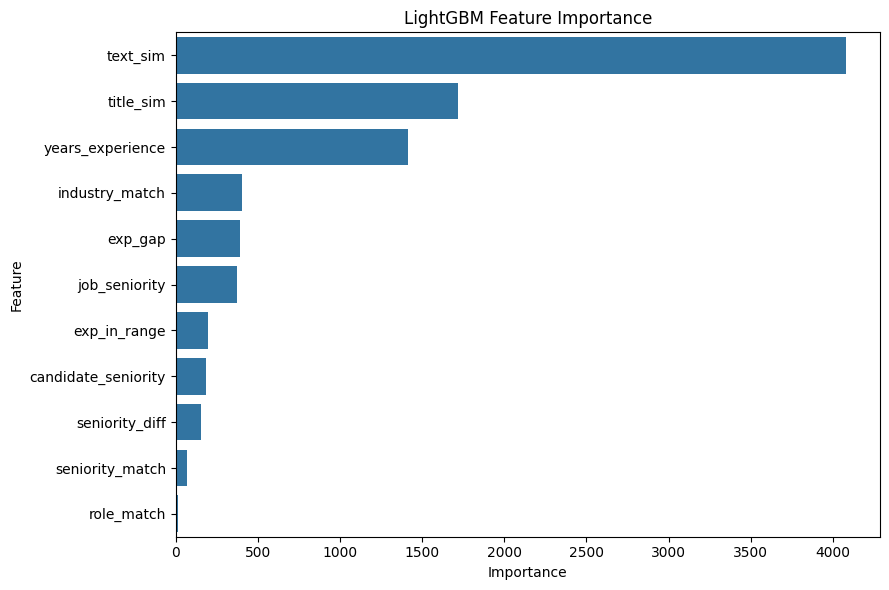

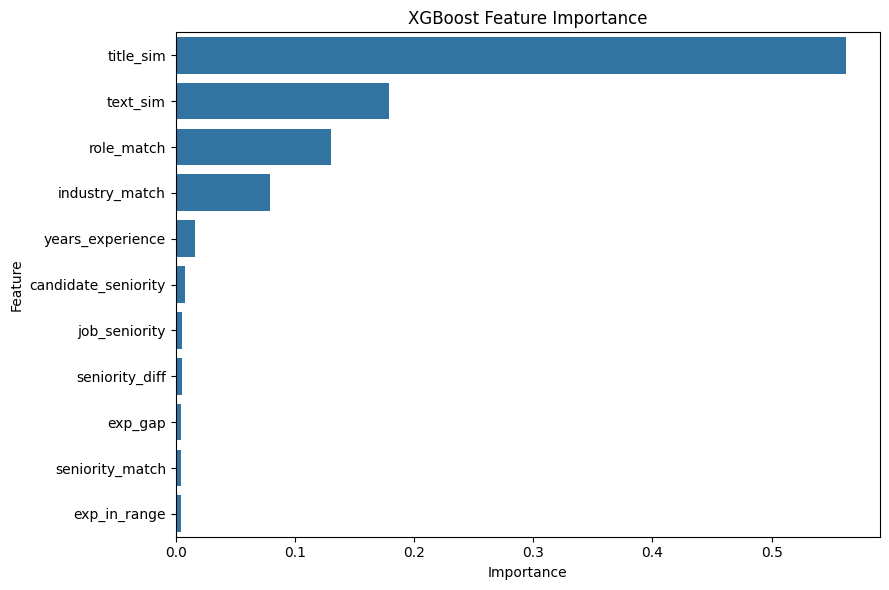

In [69]:
for model_name in [
    "Random Forest",
    "LightGBM",
    "XGBoost"
]:

    model = fitted_models[
        ("Without Skill Overlap", model_name)
    ]

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": NON_SKILL_FEATURES,
        "Importance": importances
    }).sort_values(
        "Importance",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"{model_name} Feature Importance"
    )

    plt.tight_layout()
    plt.show()

# 11. Tuning 

## 11.1. for LightGBM model

In [70]:
from scipy.stats import randint, uniform

tune_features = FEATURE_SETS["All Features"]

param_distributions = {
    "n_estimators": randint(200, 600),
    "learning_rate": uniform(0.02, 0.10),
    "num_leaves": randint(15, 64),
    "min_child_samples": randint(20, 100),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        subsample_freq=1,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1",
    cv=StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(
    train_features[tune_features],
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(search.best_params_)

print("Best CV F1:",
      round(search.best_score_, 4))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


KeyboardInterrupt: 

In [ ]:
evaluate_model(
    search.best_estimator_,
    "LightGBM (tuned)",
    "All Features",
    train_features[tune_features],
    test_features[tune_features]
)

pd.DataFrame(results).sort_values(
    ["Features", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All Features,XGBoost,0.968006,0.957618,0.982133,0.969721,0.993507
1,All Features,LightGBM (tuned),0.967693,0.957296,0.981867,0.969426,0.993364
2,All Features,LightGBM,0.967519,0.957044,0.981800,0.969264,0.993387
3,All Features,Random Forest,0.963658,0.953055,0.978533,0.965626,0.992375
4,All Features,Logistic Regression,0.946618,0.941910,0.956667,0.949231,0.984781
5,All Features,SVM,0.945401,0.939982,0.956400,0.948120,0.984738
6,All Features,Multinomial NB,0.791862,0.955902,0.630067,0.759513,0.932375
7,Without Skill Overlap,LightGBM,0.854773,0.952887,0.759133,0.845046,0.888349
8,Without Skill Overlap,XGBoost,0.854634,0.953935,0.757933,0.844714,0.887672
9,Without Skill Overlap,Random Forest,0.845349,0.933744,0.757267,0.836297,0.880086


In [ ]:
tune_features = FEATURE_SETS["Without Skill Overlap"]

param_distributions = {
    "n_estimators": randint(200, 600),
    "learning_rate": uniform(0.02, 0.10),
    "num_leaves": randint(15, 64),
    "min_child_samples": randint(20, 100),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        subsample_freq=1,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1",
    cv=StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(
    train_features[tune_features],
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(search.best_params_)

print("Best CV F1:",
      round(search.best_score_, 4))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters:
{'colsample_bytree': np.float64(0.8703100983459974), 'learning_rate': np.float64(0.02313132924555586), 'min_child_samples': 37, 'n_estimators': 417, 'num_leaves': 58, 'subsample': np.float64(0.9818496824692566)}
Best CV F1: 0.8281


In [ ]:
evaluate_model(
    search.best_estimator_,
    "LightGBM (tuned)",
    "Without Skill Overlap",
    train_features[tune_features],
    test_features[tune_features]
)

pd.DataFrame(results).sort_values(
    ["Features", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All Features,XGBoost,0.968006,0.957618,0.982133,0.969721,0.993507
1,All Features,LightGBM (tuned),0.967693,0.957296,0.981867,0.969426,0.993364
2,All Features,LightGBM,0.967519,0.957044,0.981800,0.969264,0.993387
3,All Features,Random Forest,0.963658,0.953055,0.978533,0.965626,0.992375
4,All Features,Logistic Regression,0.946618,0.941910,0.956667,0.949231,0.984781
5,All Features,SVM,0.945401,0.939982,0.956400,0.948120,0.984738
6,All Features,Multinomial NB,0.791862,0.955902,0.630067,0.759513,0.932375
7,Without Skill Overlap,LightGBM (tuned),0.855017,0.952990,0.759533,0.845335,0.888321
8,Without Skill Overlap,LightGBM,0.854773,0.952887,0.759133,0.845046,0.888349
9,Without Skill Overlap,XGBoost,0.854634,0.953935,0.757933,0.844714,0.887672


### Shared setup for Without skill overlap data tuning

In [ ]:
from scipy.stats import randint, uniform, loguniform

FEATURE_SET_NAME = "Without Skill Overlap"
no_skill_features = FEATURE_SETS[FEATURE_SET_NAME]

X_tune_train = train_features[no_skill_features]
X_tune_test = test_features[no_skill_features]

tuning_cv = GroupKFold(n_splits=3)

print(no_skill_features)

['years_experience', 'exp_in_range', 'exp_gap', 'candidate_seniority', 'job_seniority', 'seniority_match', 'seniority_diff', 'role_match', 'industry_match', 'title_sim', 'text_sim']


## 11.2: Tune Logistic Regression

In [ ]:
log_reg_search = RandomizedSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    param_distributions={
        "classifier__C": loguniform(1e-3, 1e2),
        "classifier__class_weight": [None, "balanced"]
    },
    n_iter=10,
    scoring="f1",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1
)

log_reg_search.fit(
    X_tune_train,
    y_train,
    groups=groups_train
)

print(log_reg_search.best_params_)
print("Best CV F1:", round(log_reg_search.best_score_, 4))

evaluate_model(
    log_reg_search.best_estimator_,
    "Logistic Regression (tuned)",
    FEATURE_SET_NAME,
    X_tune_train,
    X_tune_test
)

{'classifier__C': np.float64(0.008263688714158009), 'classifier__class_weight': 'balanced'}
Best CV F1: 0.7894


## 11.3 Tune SVM

In [ ]:
svm_search = RandomizedSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearSVC(
            dual=False,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),
    param_distributions={
        "classifier__C": loguniform(1e-3, 1e1),
        "classifier__class_weight": [None, "balanced"]
    },
    n_iter=10,
    scoring="f1",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1
)

svm_search.fit(
    X_tune_train,
    y_train,
    groups=groups_train
)

print(svm_search.best_params_)
print("Best CV F1:", round(svm_search.best_score_, 4))

evaluate_model(
    svm_search.best_estimator_,
    "SVM (tuned)",
    FEATURE_SET_NAME,
    X_tune_train,
    X_tune_test
)

{'classifier__C': np.float64(0.0010071984838809194), 'classifier__class_weight': 'balanced'}
Best CV F1: 0.7942


## 11.4. Tune Random Forest

In [ ]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions={
        "n_estimators": randint(200, 500),
        "max_depth": randint(6, 30),
        "min_samples_leaf": randint(1, 20),
        "max_features": ["sqrt", 0.5, 0.8],
        "class_weight": [None, "balanced"]
    },
    n_iter=10,
    scoring="f1",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_search.fit(
    X_tune_train,
    y_train,
    groups=groups_train
)

print(rf_search.best_params_)
print("Best CV F1:", round(rf_search.best_score_, 4))

evaluate_model(
    rf_search.best_estimator_,
    "Random Forest (tuned)",
    FEATURE_SET_NAME,
    X_tune_train,
    X_tune_test
)

{'class_weight': None, 'max_depth': 15, 'max_features': 0.8, 'min_samples_leaf': 15, 'n_estimators': 250}
Best CV F1: 0.8293


## 11.5. Tune XGBoost

In [ ]:
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions={
        "n_estimators": randint(200, 600),
        "learning_rate": uniform(0.02, 0.1),
        "max_depth": randint(3, 9),
        "min_child_weight": randint(1, 10),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3)
    },
    n_iter=10,
    scoring="f1",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1
)

xgb_search.fit(
    X_tune_train,
    y_train,
    groups=groups_train
)

print(xgb_search.best_params_)
print("Best CV F1:", round(xgb_search.best_score_, 4))

evaluate_model(
    xgb_search.best_estimator_,
    "XGBoost (tuned)",
    FEATURE_SET_NAME,
    X_tune_train,
    X_tune_test
)

{'colsample_bytree': np.float64(0.9727961206236346), 'learning_rate': np.float64(0.045877998160001696), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 589, 'subsample': np.float64(0.7623824988604566)}
Best CV F1: 0.8277


In [80]:
results_df = pd.DataFrame(results)

results_df[
    results_df["Features"] == FEATURE_SET_NAME
].sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Without Skill Overlap,Random Forest (tuned),0.856408,0.951491,0.763667,0.847295,0.890159
1,Without Skill Overlap,LightGBM (tuned),0.855017,0.952990,0.759533,0.845335,0.888321
2,Without Skill Overlap,LightGBM,0.854773,0.952887,0.759133,0.845046,0.888349
3,Without Skill Overlap,XGBoost (tuned),0.854704,0.952349,0.759467,0.845041,0.887659
4,Without Skill Overlap,XGBoost,0.854634,0.953935,0.757933,0.844714,0.887672
5,Without Skill Overlap,Random Forest,0.845349,0.933744,0.757267,0.836297,0.880086
6,Without Skill Overlap,SVM (tuned),0.816275,0.890210,0.738933,0.807548,0.833172
7,Without Skill Overlap,Logistic Regression (tuned),0.810363,0.878219,0.738933,0.802578,0.833028
8,Without Skill Overlap,SVM,0.805912,0.869402,0.738933,0.798876,0.836230
9,Without Skill Overlap,Logistic Regression,0.805182,0.867972,0.738933,0.798272,0.837603


# 12. Tuning with Optuna

Optuna replaces the random search above as the final tuning step. Instead of trying random settings, it uses the results of earlier trials to choose better settings for the next ones (TPE sampler), and it stops bad trials early (pruning).

**How it is set up**
- **Same folds for every model.** The 3 cross-validation folds are built once, grouped by `job_id`, so a job is never in both the training and validation part, and every model is compared on exactly the same splits.
- **Objective:** mean F1 over the 3 folds, using the **training set only**. The test set is used once per model, after tuning, so the comparison stays fair.
- **Both feature sets** are tuned for all six models, including Multinomial NB.
- **Run time:** `N_TRIALS` is the number of trials per model per feature set. 30 is a reasonable start. Lower it to test the notebook quickly, raise it for a deeper search.

Install once if needed: `pip install optuna`

In [81]:
# !pip install optuna
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import brier_score_loss
import time

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30   # trials per model per feature set

# Build the folds ONCE: every trial of every model is scored on identical splits
optuna_cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_folds = list(
    optuna_cv.split(
        train_features,
        y_train,
        groups=groups_train
    )
)

print("Folds:", len(cv_folds))
print("Trials per model per feature set:", N_TRIALS)

Folds: 3
Trials per model per feature set: 30


### Search spaces

Each function receives an Optuna `trial` and returns a model built with the settings the trial chose. Keeping every model in one function makes the later code identical for all six models.

For **Multinomial NB** Optuna also chooses how the features are prepared: `minmax` (scale to 0 to 1) or `kbins` (cut each feature into bins and one-hot encode the bin, which turns continuous numbers into count-like columns that Multinomial NB handles better), plus `alpha` (smoothing) and `fit_prior`.

In [82]:
def build_logreg(trial):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 1e2, log=True),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])


def build_svm(trial):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearSVC(
            C=trial.suggest_float("C", 1e-3, 1e1, log=True),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            dual=False,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])


def build_rf(trial):
    return RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 4, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8]),
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
        n_jobs=-1,
        random_state=RANDOM_STATE
    )


def build_xgb(trial):
    return XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )


def build_lgbm(trial):
    return LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        n_jobs=-1,
        verbose=-1,
        random_state=RANDOM_STATE
    )


def build_mnb(trial):
    preprocess = trial.suggest_categorical("preprocess", ["minmax", "kbins"])

    if preprocess == "minmax":
        prep = MinMaxScaler(clip=True)
    else:
        prep = KBinsDiscretizer(
            n_bins=trial.suggest_int("n_bins", 3, 20),
            encode="onehot",
            strategy=trial.suggest_categorical("bin_strategy", ["uniform", "quantile"])
        )

    return Pipeline([
        ("prep", prep),
        ("classifier", MultinomialNB(
            alpha=trial.suggest_float("alpha", 1e-3, 10, log=True),
            fit_prior=trial.suggest_categorical("fit_prior", [True, False])
        ))
    ])

### Tuning function

`tune_with_optuna` runs one study for one model and one feature set:

1. Each trial builds a model from the chosen settings and scores it on the 3 folds (mean F1). If a trial is clearly worse than the median after the first folds, it is stopped early.
2. After `N_TRIALS` trials, the best settings are used to train a fresh model on the full training set.
3. That model goes through the same `evaluate_model` helper as before, so it is added to `results` under the name `"<model> (Optuna)"`.

In [83]:
studies = {}
optuna_summary = []


def tune_with_optuna(model_name, build_fn, feature_set_name, n_trials=N_TRIALS):
    features = FEATURE_SETS[feature_set_name]
    X_tr = train_features[features]
    X_te = test_features[features]

    def objective(trial):
        base_model = build_fn(trial)
        fold_scores = []

        for step, (fit_idx, val_idx) in enumerate(cv_folds):
            model = clone(base_model)
            model.fit(X_tr.iloc[fit_idx], y_train.iloc[fit_idx])
            preds = model.predict(X_tr.iloc[val_idx])
            fold_scores.append(f1_score(y_train.iloc[val_idx], preds))

            trial.report(float(np.mean(fold_scores)), step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_warmup_steps=1)
    )

    start = time.time()
    study.optimize(objective, n_trials=n_trials)
    seconds = time.time() - start

    # Rebuild the best model from its settings and evaluate it on the test set
    best_model = build_fn(optuna.trial.FixedTrial(study.best_params))

    evaluate_model(
        best_model,
        f"{model_name} (Optuna)",
        feature_set_name,
        X_tr,
        X_te
    )

    studies[(feature_set_name, model_name)] = study

    optuna_summary.append({
        "Features": feature_set_name,
        "Model": model_name,
        "Best CV F1": round(study.best_value, 4),
        "Test F1": round(results[-1]["F1"], 4),
        "Pruned trials": sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials),
        "Seconds": round(seconds),
        "Best params": study.best_params
    })

    print(f"{model_name} | {feature_set_name} | CV F1 = {study.best_value:.4f} | "
          f"Test F1 = {results[-1]['F1']:.4f} | {seconds:.0f}s")

    return study

## 12.1. Logistic Regression

In [84]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("Logistic Regression", build_logreg, feature_set_name)

Logistic Regression | All Features | CV F1 = 0.9483 | Test F1 = 0.9496 | 29s
Logistic Regression | Without Skill Overlap | CV F1 = 0.7934 | Test F1 = 0.8078 | 12s


## 12.2. SVM

In [85]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("SVM", build_svm, feature_set_name)

SVM | All Features | CV F1 = 0.9475 | Test F1 = 0.9482 | 38s
SVM | Without Skill Overlap | CV F1 = 0.7941 | Test F1 = 0.8074 | 19s


## 12.3. Random Forest

In [87]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("Random Forest", build_rf, feature_set_name)

[W 2026-10-04 11:30:37,210] Trial 23 failed with parameters: {'n_estimators': 318, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 0.8, 'class_weight': None} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Me\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Me\AppData\Local\Temp\ipykernel_23336\1050883208.py", line 16, in objective
    model.fit(X_tr.iloc[fit_idx], y_train.iloc[fit_idx])
  File "c:\Users\Me\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Me\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py", line 487, in fit
    trees = Parallel(
            ^^^^^^^^^
  File "c:\

KeyboardInterrupt: 

## 12.4. XGBoost

In [ ]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("XGBoost", build_xgb, feature_set_name)

XGBoost | All Features | CV F1 = 0.9673 | Test F1 = 0.9695 | 137s
XGBoost | Without Skill Overlap | CV F1 = 0.8279 | Test F1 = 0.8448 | 79s


## 12.5. LightGBM

In [ ]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("LightGBM", build_lgbm, feature_set_name)

LightGBM | All Features | CV F1 = 0.9678 | Test F1 = 0.9696 | 237s
LightGBM | Without Skill Overlap | CV F1 = 0.8279 | Test F1 = 0.8450 | 135s


## 12.6. Multinomial Naïve Bayes

In [ ]:
for feature_set_name in FEATURE_SETS:
    tune_with_optuna("Multinomial NB", build_mnb, feature_set_name)

Multinomial NB | All Features | CV F1 = 0.9406 | Test F1 = 0.9410 | 12s
Multinomial NB | Without Skill Overlap | CV F1 = 0.7960 | Test F1 = 0.8112 | 7s


### Optuna Results

The table shows, for each model, the best cross-validation F1 (on the training jobs), the F1 on the held-out test jobs, and the best settings found. A small gap between **Best CV F1** and **Test F1** means the tuning did not overfit the validation folds.

In [ ]:
optuna_df = pd.DataFrame(optuna_summary)

optuna_df.sort_values(
    ["Features", "Test F1"],
    ascending=[True, False]
).reset_index(drop=True)

,Features,Model,Best CV F1,Test F1,Pruned trials,Seconds,Best params
0,All Features,LightGBM,0.9678,0.9696,8,237,"{'n_estimators': 511, 'learning_rate': 0.04685..."
1,All Features,XGBoost,0.9673,0.9695,19,137,"{'n_estimators': 503, 'learning_rate': 0.05358..."
2,All Features,Random Forest,0.9648,0.9673,11,914,"{'n_estimators': 287, 'max_depth': 12, 'min_sa..."
3,All Features,Logistic Regression,0.9483,0.9496,11,35,"{'C': 8.94610406867191, 'class_weight': None}"
4,All Features,SVM,0.9475,0.9482,20,48,"{'C': 0.03148911647956861, 'class_weight': None}"
5,All Features,Multinomial NB,0.9406,0.9410,13,12,"{'preprocess': 'kbins', 'n_bins': 17, 'bin_str..."
6,Without Skill Overlap,Random Forest,0.8329,0.8506,10,392,"{'n_estimators': 254, 'max_depth': 19, 'min_sa..."
7,Without Skill Overlap,LightGBM,0.8279,0.8450,8,135,"{'n_estimators': 310, 'learning_rate': 0.11316..."
8,Without Skill Overlap,XGBoost,0.8279,0.8448,9,79,"{'n_estimators': 148, 'learning_rate': 0.12949..."
9,Without Skill Overlap,Multinomial NB,0.7960,0.8112,21,7,"{'preprocess': 'kbins', 'n_bins': 10, 'bin_str..."


### Multinomial NB vs the Other Models (after Optuna)

For each feature set, the tuned Multinomial NB is compared with the best of the other five tuned models. The **Brier score** is added because the app shows the probability as a match percentage: lower is better, and it tells us how trustworthy that percentage is (Naïve Bayes is known for over-confident probabilities).

In [ ]:
results_df = pd.DataFrame(results)
is_optuna = results_df["Model"].str.endswith("(Optuna)")

for feature_set_name in FEATURE_SETS:
    subset = results_df[
        (results_df["Features"] == feature_set_name) & is_optuna
    ].sort_values("F1", ascending=False).reset_index(drop=True)

    print(f"\n=== {feature_set_name} ===")
    display(subset)

    mnb_row = subset[subset["Model"] == "Multinomial NB (Optuna)"].iloc[0]
    top_row = subset[subset["Model"] != "Multinomial NB (Optuna)"].iloc[0]

    X_te = test_features[FEATURE_SETS[feature_set_name]]
    brier_mnb = brier_score_loss(
        y_test,
        fitted_models[(feature_set_name, "Multinomial NB (Optuna)")].predict_proba(X_te)[:, 1]
    )

    top_model = fitted_models[(feature_set_name, top_row["Model"])]
    if hasattr(top_model, "predict_proba"):
        brier_top = brier_score_loss(y_test, top_model.predict_proba(X_te)[:, 1])
    else:
        brier_top = float("nan")

    print(f"Multinomial NB : F1 = {mnb_row['F1']:.4f} | ROC-AUC = {mnb_row['ROC-AUC']:.4f} | Brier = {brier_mnb:.4f}")
    print(f"{top_row['Model']:<22}: F1 = {top_row['F1']:.4f} | ROC-AUC = {top_row['ROC-AUC']:.4f} | Brier = {brier_top:.4f}")

    if mnb_row["F1"] > top_row["F1"]:
        print("-> Multinomial NB is better on this feature set.")
    else:
        print("-> Multinomial NB is NOT better on this feature set.")


=== All Features ===


,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,All Features,LightGBM (Optuna),0.967901,0.957551,0.982000,0.969621,0.993522
1,All Features,XGBoost (Optuna),0.967832,0.957664,0.981733,0.969549,0.993545
2,All Features,Random Forest (Optuna),0.965397,0.955033,0.979800,0.967258,0.992588
3,All Features,Logistic Regression (Optuna),0.946931,0.941770,0.957467,0.949554,0.984743
4,All Features,SVM (Optuna),0.945505,0.940571,0.955933,0.948190,0.984841
5,All Features,Multinomial NB (Optuna),0.938654,0.944878,0.937067,0.940956,0.983382


Multinomial NB : F1 = 0.9410 | ROC-AUC = 0.9834 | Brier = 0.0515
LightGBM (Optuna)     : F1 = 0.9696 | ROC-AUC = 0.9935 | Brier = 0.0254
-> Multinomial NB is NOT better on this feature set.

=== Without Skill Overlap ===


,Features,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Without Skill Overlap,Random Forest (Optuna),0.859224,0.953086,0.767933,0.850550,0.892806
1,Without Skill Overlap,LightGBM (Optuna),0.854043,0.947181,0.762733,0.845009,0.888527
2,Without Skill Overlap,XGBoost (Optuna),0.854356,0.951252,0.759733,0.844774,0.888125
3,Without Skill Overlap,Multinomial NB (Optuna),0.820588,0.899164,0.738933,0.811212,0.844349
4,Without Skill Overlap,Logistic Regression (Optuna),0.816554,0.890782,0.738933,0.807783,0.833230
5,Without Skill Overlap,SVM (Optuna),0.816136,0.889924,0.738933,0.807430,0.833170


Multinomial NB : F1 = 0.8112 | ROC-AUC = 0.8443 | Brier = 0.1560
Random Forest (Optuna): F1 = 0.8506 | ROC-AUC = 0.8928 | Brier = 0.1097
-> Multinomial NB is NOT better on this feature set.


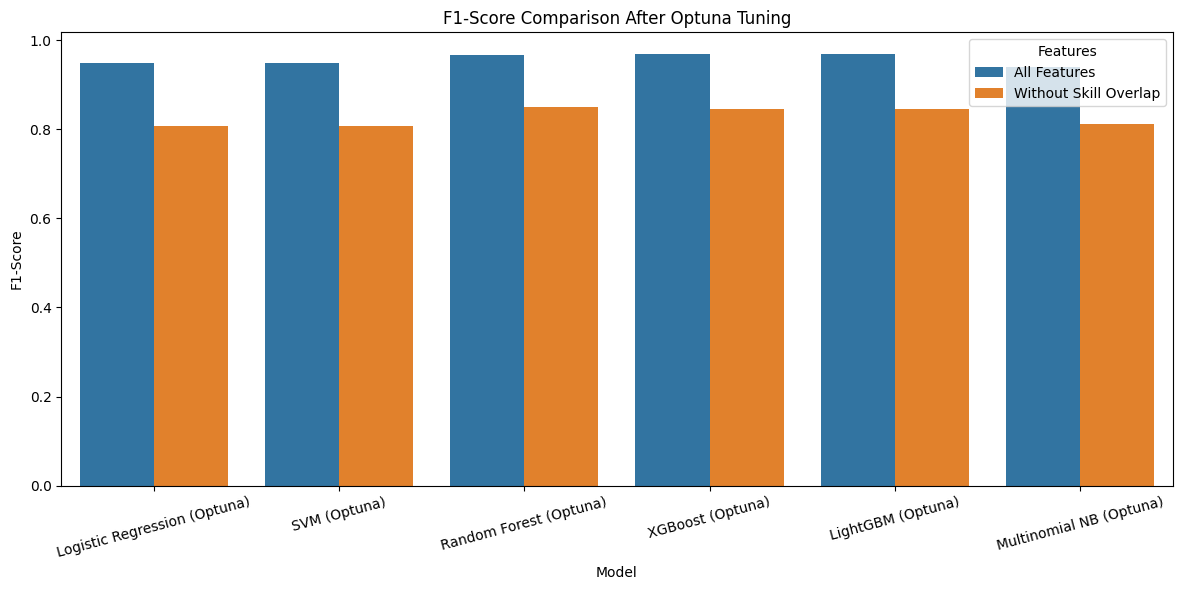

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df[is_optuna],
    x="Model",
    y="F1",
    hue="Features"
)

plt.title("F1-Score Comparison After Optuna Tuning")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

The final model in the next section is chosen automatically as the row with the highest F1 across **all** results (baseline and Optuna). If Multinomial NB is the best, it is saved and used by the app. Otherwise the best model stays, and the cell prints how Multinomial NB compared.

# 13. Final Model and NLP Artifacts

In [71]:
results_df = pd.DataFrame(results)

no_overlap_results = results_df.loc[
    results_df["Features"] == "Without Skill Overlap"
]

if no_overlap_results.empty:
    raise ValueError("No results found for the 'Without Skill Overlap' feature set.")

best_row = no_overlap_results.loc[
    no_overlap_results["F1"].idxmax()
]

best_features_name = best_row["Features"]
best_model_name = best_row["Model"]

best_model = fitted_models[
    (best_features_name, best_model_name)
]

best_features = FEATURE_SETS[best_features_name]

print("Selected model:", best_model_name)
print("Feature set:", best_features_name)
print("F1-score:", round(best_row["F1"], 4))
print("ROC-AUC:", round(best_row["ROC-AUC"], 4))


Selected model: LightGBM
Feature set: Without Skill Overlap
F1-score: 0.845
ROC-AUC: 0.8883


In [89]:
joblib.dump(
    {
        "model": best_model,
        "features": best_features,
        "feature_set_name": best_features_name,
        "model_name": best_model_name
    },
    "ai_resume_job_match_model.joblib"
)

['ai_resume_job_match_model.joblib']

In [90]:
joblib.dump(
    {
        "tfidf_text": tfidf_text,
        "tfidf_title": tfidf_title,
        "tfidf_skills": tfidf_skills,
        "SKILL_VOCAB": SKILL_VOCAB,
        "SKILL_ALIASES": SKILL_ALIASES,
        "SKILL_FEATURES": SKILL_FEATURES,
        "NON_SKILL_FEATURES": NON_SKILL_FEATURES,
        "ALL_FEATURES": ALL_FEATURES,
        "KNOWN_ROLES": KNOWN_ROLES
    },
    "ai_resume_job_match_nlp_artifacts.joblib"
)

['ai_resume_job_match_nlp_artifacts.joblib']

# 14. Test with a New Resume

The final stage demonstrates how a new resume can be processed using the same NLP pipeline used during development.

The resume is:

1. Converted to text.
2. Processed using the NLP functions.
3. Converted into a candidate profile.
4. Compared against a job profile.
5. Converted into the same model features.
6. Passed to the trained model.

The same preprocessing and feature representation must be used during deployment to ensure consistency between training and inference.

In [91]:
def build_candidate_profile(cv_text):
    years = extract_years_experience(cv_text)

    titles = extract_job_titles(cv_text)

    role = (
        titles[0]
        if titles
        else canonical_role(
            str(cv_text)[:200]
        )
    )

    return {
        "role": role,
        "seniority": extract_seniority(
            cv_text,
            years
        ),
        "years_experience": (
            years
        ),
        "industry": "Unknown",
        "education": extract_education(
            cv_text
        ),
        "skills": extract_skills(
            cv_text
        ),
        "titles": titles,
        "text": preprocess_text(
            cv_text
        )
    }

In [92]:
def extract_required_years(text):
    numbers = [
        int(x)
        for x in re.findall(
            r"(\d{1,2})\s*\+?\s*(?:years?|yrs?)",
            str(text).lower()
        )
    ]

    return min(numbers) if numbers else None


def extract_education_requirement(text):
    level = extract_education(text)

    return (
        None
        if level == "Unknown"
        else level
    )


def build_job_profile(
    title,
    description,
    tags=None,
    industry="Unknown"
):
    blob = (
        f"{title} "
        f"{description} "
        f"{' '.join(tags or [])}"
    )

    skills = extract_skills(blob)

    title_low = str(title).lower()

    if re.search(
        r"senior|\bsr\b|lead|principal|"
        r"junior|\bjr\b|intern|entry",
        title_low
    ):
        seniority = extract_seniority(title)

    else:
        required_years = (
            extract_required_years(blob)
        )

        seniority = (
            years_to_seniority(
                required_years
            )
            if required_years is not None
            else "Mid"
        )

    return {
        "title": canonical_role(title),
        "raw_title": title,
        "seniority": seniority,
        "industry": industry,
        "must_have": skills,
        "nice_to_have": [],
        "required_years": (
            extract_required_years(blob)
        ),
        "education_required": (
            extract_education_requirement(
                blob
            )
        ),
        "text": preprocess_text(
            f"{title} {description}"
        )
    }

The functions above will later be reused by the Streamlit application to process uploaded resumes and job descriptions.

In [93]:
# Example resume
test_cv = """
John Doe

Software Engineer with 4 years of experience.

Education:
Bachelor of Science in Computer Science.

Skills:
Python, Java, SQL, Git, Docker, REST APIs, Machine Learning.

Experience:
Worked as a software engineer developing Python applications,
REST APIs and machine learning systems.
"""

# Example job
test_job_title = "Software Engineer"

test_job_description = """
We are looking for a Software Engineer with experience in Python,
SQL, REST APIs, Git and Docker.

The candidate should have experience developing software
applications and working with machine learning systems.
"""

candidate = build_candidate_profile(test_cv)

job = build_job_profile(
    test_job_title,
    test_job_description
)

print("CANDIDATE PROFILE")
print(candidate)

print("\nJOB PROFILE")
print(job)

CANDIDATE PROFILE
{'role': 'Software Engineer', 'seniority': 'Mid', 'years_experience': 4, 'industry': 'Unknown', 'education': 'BSc', 'skills': ['Docker', 'Git', 'Java', 'Python', 'REST APIs', 'SQL'], 'titles': ['Software Engineer'], 'text': 'john doe software engineer years experience education bachelor science computer science skills python java sql git docker rest apis machine learning experience worked software engineer developing python applications rest apis machine learning systems'}

JOB PROFILE
{'title': 'Software Engineer', 'raw_title': 'Software Engineer', 'seniority': 'Mid', 'industry': 'Unknown', 'must_have': ['Docker', 'Git', 'Python', 'REST APIs', 'SQL'], 'nice_to_have': [], 'required_years': None, 'education_required': None, 'text': 'software engineer looking software engineer experience python sql rest apis git docker candidate experience developing software applications working machine learning systems'}


In [94]:
print("Extracted skills:")
print(candidate["skills"])

print("\nExperience:")
print(candidate["years_experience"])

print("\nEducation:")
print(candidate["education"])

print("\nSeniority:")
print(candidate["seniority"])

print("\nJob required skills:")
print(job["must_have"])

Extracted skills:
['Docker', 'Git', 'Java', 'Python', 'REST APIs', 'SQL']

Experience:
4

Education:
BSc

Seniority:
Mid

Job required skills:
['Docker', 'Git', 'Python', 'REST APIs', 'SQL']


In [95]:
def match_resume_to_job(
    resume_text,
    job_title,
    job_description,
    tags=None,
    industry="Unknown"
):
    # Build candidate and job profiles
    candidate = build_candidate_profile(resume_text)

    job = build_job_profile(
        title=job_title,
        description=job_description,
        tags=tags,
        industry=industry
    )

    # Create the same features used during training
    features = make_features(
        [candidate],
        [job]
    )

    # Keep only the features used by the selected model
    X = features[best_features]

    # Prediction
    prediction = best_model.predict(X)[0]

    # Probability / confidence
    if hasattr(best_model, "predict_proba"):
        probability = best_model.predict_proba(X)[0, 1]
    else:
        decision_score = best_model.decision_function(X)[0]
        probability = 1 / (1 + np.exp(-decision_score))

    # Skill analysis
    candidate_skills = set(candidate["skills"])
    required_skills = set(job["must_have"])

    matching_skills = sorted(
        candidate_skills & required_skills
    )

    missing_skills = sorted(
        required_skills - candidate_skills
    )

    result = {
        "prediction": (
            "Match"
            if prediction == 1
            else "Not a Match"
        ),
        "match_probability": round(
            probability * 100,
            2
        ),
        "candidate_profile": candidate,
        "job_profile": job,
        "matching_skills": matching_skills,
        "missing_skills": missing_skills,
        "skill_coverage": round(
            len(matching_skills) / len(required_skills) * 100,
            2
        ) if required_skills else 0
    }

    return result

In [96]:
result = match_resume_to_job(
    resume_text=test_cv,
    job_title=test_job_title,
    job_description=test_job_description
)

result

{'prediction': 'Match',
 'match_probability': np.float64(93.83),
 'candidate_profile': {'role': 'Software Engineer',
  'seniority': 'Mid',
  'years_experience': 4,
  'industry': 'Unknown',
  'education': 'BSc',
  'skills': ['Docker', 'Git', 'Java', 'Python', 'REST APIs', 'SQL'],
  'titles': ['Software Engineer'],
  'text': 'john doe software engineer years experience education bachelor science computer science skills python java sql git docker rest apis machine learning experience worked software engineer developing python applications rest apis machine learning systems'},
 'job_profile': {'title': 'Software Engineer',
  'raw_title': 'Software Engineer',
  'seniority': 'Mid',
  'industry': 'Unknown',
  'must_have': ['Docker', 'Git', 'Python', 'REST APIs', 'SQL'],
  'nice_to_have': [],
  'required_years': None,
  'education_required': None,
  'text': 'software engineer looking software engineer experience python sql rest apis git docker candidate experience developing software applicati

In [97]:
print("Prediction:", result["prediction"])
print("Match Probability:", f'{result["match_probability"]}%')
print("Skill Coverage:", f'{result["skill_coverage"]}%')

print("\nMatching Skills:")
print(result["matching_skills"])

print("\nMissing Skills:")
print(result["missing_skills"])

Prediction: Match
Match Probability: 93.83%
Skill Coverage: 100.0%

Matching Skills:
['Docker', 'Git', 'Python', 'REST APIs', 'SQL']

Missing Skills:
[]


In [ ]:
import shap

# best_model is the tuned XGBoost -> TreeExplainer is exact and fast
explainer = shap.TreeExplainer(best_model)
X_test = test_features[best_features]
shap_values = explainer.shap_values(X_test)

# Which features matter most across the whole test set
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)
# Direction + spread: red = high feature value, right = pushes toward "Match"
shap.summary_plot(shap_values, X_test, show=True)


# ── CELL 2: explain ONE resume/job prediction ──────────────────
def explain_match(resume_text, job_title, job_description,
                  tags=None, industry="Unknown", top_n=8, plot=True):
    candidate = build_candidate_profile(resume_text)
    job = build_job_profile(
        title=job_title, description=job_description,
        tags=tags, industry=industry,
    )
    X = make_features([candidate], [job])[best_features]

    sv = explainer.shap_values(X)[0]
    base = float(np.ravel(explainer.expected_value)[0])

    contrib = (
        pd.DataFrame({
            "feature": best_features,
            "value": X.iloc[0].values,
            "shap": sv,
        })
        .assign(abs_shap=lambda d: d["shap"].abs())
        .sort_values("abs_shap", ascending=False)
        .drop(columns="abs_shap")
        .reset_index(drop=True)
    )
    contrib["effect"] = np.where(contrib["shap"] > 0, "toward Match", "toward Not a Match")

    if plot:
        shap.plots.waterfall(
            shap.Explanation(
                values=sv, base_values=base,
                data=X.iloc[0].values, feature_names=list(best_features),
            ),
            max_display=top_n,
        )
    return contrib.head(top_n)


# ── CELL 3: try it on the example from section 17 ──────────────
explain_match(test_cv, test_job_title, test_job_description)

# NOTE: SHAP values for XGBoost are in log-odds, not percentage points.
# base + sum(shap) = the model's raw score; sigmoid(score) = match probability.
